# QDF Rust 파이프라인 실행 노트북

이 노트북은 `QuantumDeepField_molecule/` 안에 새로 추가한 Rust 기반 구현들을 **선택적으로** 실행/검증/벤치합니다.

**규칙**: 기존 NumPy/PyTorch 경로는 절대 삭제하지 않았습니다. 모든 셀은 `BACKEND`, `LOADER`, `PAD_IMPL` 같은 변수로 **기존 vs Rust** 를 선택할 수 있습니다.

## 셀 순서
1. 환경 확인 (Python / torch / XPU / qdf_io)
2. (선택) `qdf_io` Rust 확장 빌드
3. 전처리 — `--backend {numpy,rust}` 선택
4. 전처리 정확성 검증 (numpy vs rust)
5. `.npy/` → 단일 shard 변환
6. shard 정확성 검증 (`MyDataset` vs `MyDatasetShard`)
7. Training 프로파일 — `--loader {npy,shard}` × `--pad-impl {python,rust,rust-pad-only}`
8. LCAO 패치 정확성 검증 (python vs rust)
9. (참고) 단일 스레드 전처리 micro-bench

## 0. 공통 설정

이 셀에서 데이터셋 이름과 기본 격자 파라미터를 정합니다. 아래 모든 셀이 이 변수들을 참조합니다.

**데이터셋**: `QuantumDeepField_molecule/dataset/<DATASET>/` 에 `train.txt`, `val.txt`, `test.txt` 가 있어야 `preprocess.py`가 동작합니다. 레포에 기본 포함된 예시는 `QM9under7atoms_atomizationenergy_eV`, `QM9under7atoms_homolumo_eV`, `QM9full_homolumo_eV` 등입니다. `QM9under14atoms_atomizationenergy_eV` 는 용량이 커서 원문 split을 직접 넣어야 합니다.

In [2]:
import os
import shlex
import subprocess
import sys
from pathlib import Path

# Resolve repo paths (notebook lives in QuantumDeepField_molecule/bench/).
NB_DIR = Path.cwd()
if NB_DIR.name != "bench":
    # When the notebook is opened from elsewhere, normalize cwd.
    NB_DIR = Path("QuantumDeepField_molecule/bench").resolve()
QDF_ROOT = NB_DIR.parent
REPO_ROOT = QDF_ROOT.parent
PY = Path(sys.executable)

# --- USER CHOICES ---------------------------------------------------------
# Repo ships small QM9 splits under dataset/. Under-14 atomization requires you
# to place train.txt / val.txt / test.txt under dataset/<name>/ yourself.
DATASET = "QM9under14atoms_atomizationenergy_eV"
BASIS_SET = "6-31G"
RADIUS = "0.75"
GRID_INTERVAL = "0.3"
OPERATION = "sum"   # 'sum' for atomization energy, 'mean' for homo/lumo

# CPU count reported in the output folder name (informational; does NOT limit threads).
N_CPUS = 4
# --------------------------------------------------------------------------

print(f"REPO_ROOT     : {REPO_ROOT}")
print(f"QDF_ROOT      : {QDF_ROOT}")
print(f"Python        : {PY}")
print(f"Dataset       : {DATASET}")
print(f"Field         : basis_set={BASIS_SET}, radius={RADIUS}, grid_interval={GRID_INTERVAL}")
print(f"N_CPUS        : {N_CPUS}")

def run(cmd, cwd=REPO_ROOT, check=True):
    """Run a subprocess synchronously and stream output line-by-line."""
    if isinstance(cmd, str):
        shown = cmd
        args = cmd if os.name == "nt" else shlex.split(cmd)
        shell = True
    else:
        shown = " ".join(str(a) for a in cmd)
        args = [str(a) for a in cmd]
        shell = False
    print(f"$ {shown}\n  (cwd={cwd})")
    proc = subprocess.Popen(
        args, cwd=str(cwd), shell=shell,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
        bufsize=1, encoding="utf-8", errors="replace",
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    proc.wait()
    if check and proc.returncode != 0:
        raise RuntimeError(f"Command failed (rc={proc.returncode}): {shown}")
    return proc.returncode

REPO_ROOT     : /home/ubuntu/3DGCL
QDF_ROOT      : /home/ubuntu/3DGCL/QuantumDeepField_molecule
Python        : /home/ubuntu/3DGCL/.venv/bin/python
Dataset       : QM9under14atoms_atomizationenergy_eV
Field         : basis_set=6-31G, radius=0.75, grid_interval=0.3
N_CPUS        : 4


## 1. 환경 확인 — Python / torch / XPU / qdf_io

In [3]:
import platform
import torch

print(f"OS           : {platform.platform()}")
print(f"Python       : {sys.version.split()[0]}")
print(f"torch        : {torch.__version__}")
print(f"CUDA avail   : {torch.cuda.is_available()}")
print(f"XPU  avail   : {getattr(torch, 'xpu', None) is not None and torch.xpu.is_available()}")
if hasattr(torch, "xpu") and torch.xpu.is_available():
    print(f"XPU device   : {torch.xpu.get_device_name(0)}")
print(f"CPU cores    : {os.cpu_count()}")

try:
    import qdf_io  # type: ignore
    info = qdf_io.format_info()
    print("qdf_io       : OK", info)
    QDF_IO_AVAILABLE = True
except Exception as e:  # pragma: no cover
    print(f"qdf_io       : NOT BUILT  ({e})")
    print("               -> run the 'Build qdf_io' cell below.")
    QDF_IO_AVAILABLE = False

OS           : Linux-6.17.0-1011-oracle-aarch64-with-glibc2.39
Python       : 3.10.20
torch        : 2.5.1
CUDA avail   : False
XPU  avail   : False
CPU cores    : 4
qdf_io       : OK {'magic': [81, 68, 70, 83, 72, 82, 68, 0], 'version': 1, 'header_size': 64, 'flag_has_property': 1}


## 2. (선택) `qdf_io` Rust 확장 빌드

처음 한 번만 실행하면 됩니다. 의존성이 바뀐 후에도 다시 실행.

이미 빌드되어 있으면 `BUILD_QDF_IO = False`로 두고 건너뜁니다.

In [4]:
BUILD_QDF_IO = not QDF_IO_AVAILABLE

# Some Rust changes only ship a new symbol (e.g. ``ShardWriter``). If you
# already have ``qdf_io`` imported but the new symbol is missing, set this
# to True to force a rebuild even though the current binary loads. The
# rebuild may fail on Windows if the .pyd is still locked by the active
# kernel — see the wheel fallback below.
FORCE_REBUILD_IF_MISSING_SHARDWRITER = True
if QDF_IO_AVAILABLE and FORCE_REBUILD_IF_MISSING_SHARDWRITER:
    try:
        from qdf_io import ShardWriter  # noqa: F401
    except Exception:
        BUILD_QDF_IO = True


def _try_install_wheel():
    """Install the most recent locally built wheel (idempotent, no rebuild).

    Useful when ``maturin develop`` cannot overwrite the loaded .pyd on
    Windows: we still produced a wheel under ``qdf_io/target/wheels/``.
    """
    wheels_dir = QDF_ROOT / "qdf_io" / "target" / "wheels"
    if not wheels_dir.exists():
        return False
    candidates = sorted(wheels_dir.glob("qdf_io-*.whl"))
    if not candidates:
        return False
    wheel = candidates[-1]
    print(f"Falling back to wheel install: {wheel}")
    try:
        run([PY, "-m", "pip", "install", "--force-reinstall", "--no-deps", str(wheel)])
        return True
    except Exception as e:
        print(f"  wheel install failed: {e}")
        return False


if BUILD_QDF_IO:
    maturin = Path(PY).with_name("maturin.exe" if os.name == "nt" else "maturin")
    if not maturin.exists():
        print("maturin not found, installing via the same Python interpreter...")
        try:
            run([PY, "-m", "pip", "install", "maturin>=1.7,<2"])
        except Exception:
            run(["uv", "pip", "install", "maturin>=1.7,<2"])
    try:
        run([str(maturin), "develop", "--release"], cwd=QDF_ROOT / "qdf_io")
    except Exception as e:
        print(f"maturin develop failed (likely locked .pyd): {e}")
        # On Windows the .pyd is locked while the current kernel has it
        # loaded. Build a wheel (does not touch the loaded file) so a
        # *new* kernel will pick the new code up.
        try:
            run([str(maturin), "build", "--release"], cwd=QDF_ROOT / "qdf_io")
        except Exception as e2:
            print(f"maturin build also failed: {e2}")
        installed = _try_install_wheel()
        if not installed:
            print(
                "\nCould not refresh qdf_io in-place. The wheel is built under\n"
                "  QuantumDeepField_molecule/qdf_io/target/wheels/\n"
                "Restart this kernel and re-run the cell to pick it up."
            )
    import importlib
    if "qdf_io" in sys.modules:
        try:
            importlib.reload(sys.modules["qdf_io"])
        except Exception:
            pass
    import qdf_io  # noqa: F401
    print("qdf_io     :", qdf_io.format_info())
    print("has ShardWriter:", hasattr(qdf_io, "ShardWriter"))
else:
    print("Skipping build (qdf_io already importable). Set BUILD_QDF_IO = True to force.")

Skipping build (qdf_io already importable). Set BUILD_QDF_IO = True to force.


## 3. 전처리 — `train/preprocess.py`

`PREPROCESS_BACKEND`를 바꿔 NumPy/SciPy 경로(기존)와 Rust+Rayon 경로(새로운) 중 선택할 수 있습니다.

- `"numpy"` (기본): 원본 SciPy `distance_matrix` 그대로.
- `"rust"`        : `qdf_io.preprocess_batch_rust` (Rayon 병렬, GIL 해제).

기존 `*.npy` 출력 위치(`<dataset>/<split>_<basis>_<r>sphere_<g>grid/`)는 두 경로가 동일합니다.

In [5]:
# Choose 'numpy' or 'rust'. Set RUN_PREPROCESS = False to skip (e.g. data already exists).
RUN_PREPROCESS = True
PREPROCESS_BACKEND = "rust"          # 'numpy' or 'rust'
PREPROCESS_RUST_BATCH_SIZE = 64       # only used when backend == 'rust'

if RUN_PREPROCESS:
    cmd = [
        PY, QDF_ROOT / "train" / "preprocess.py",
        DATASET, BASIS_SET, RADIUS, GRID_INTERVAL,
        "--backend", PREPROCESS_BACKEND,
        "--rust-batch-size", str(PREPROCESS_RUST_BATCH_SIZE),
    ]
    run(cmd)
else:
    print("Skipping preprocess (RUN_PREPROCESS = False).")

$ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/train/preprocess.py QM9under14atoms_atomizationenergy_eV 6-31G 0.75 0.3 --backend rust --rust-batch-size 64
  (cwd=/home/ubuntu/3DGCL)
Preprocess QM9under14atoms_atomizationenergy_eV dataset.
The preprocessed dataset is saved in /home/ubuntu/3DGCL/QuantumDeepField_molecule/dataset/QM9under14atoms_atomizationenergy_eV/ directory.
If the dataset size is large, it takes a long time and consume storage.
Wait for a while...
Backend: rust (rust_batch_size=64)   output: npy
--------------------------------------------------
Training dataset...
10％ has finished.
50％ has finished.
90％ has finished.
--------------------------------------------------
Validation dataset...
10％ has finished.
50％ has finished.
90％ has finished.
--------------------------------------------------
Test dataset...
10％ has finished.
50％ has finished.
90％ has finished.
--------------------------------------------------
The preprocess has fi

## 4. 전처리 정확성 검증 — numpy vs rust

두 백엔드의 `distance_matrix(field, orbitals)` 및 `potential` 출력이 `rtol/atol = 1e-5` 이내에서 일치하는지 확인.

In [6]:
RUN_VERIFY_PREPROCESS = True
VERIFY_LIMIT = 200
VERIFY_SPLIT = "train"

if RUN_VERIFY_PREPROCESS:
    cmd = [
        PY, QDF_ROOT / "bench" / "verify_preprocess_backend.py",
        "--dataset", DATASET,
        "--split", VERIFY_SPLIT,
        "--basis-set", BASIS_SET,
        "--radius", RADIUS,
        "--grid-interval", GRID_INTERVAL,
        "--limit", str(VERIFY_LIMIT),
    ]
    run(cmd)
else:
    print("Skipping preprocess backend verification.")

$ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/verify_preprocess_backend.py --dataset QM9under14atoms_atomizationenergy_eV --split train --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --limit 200
  (cwd=/home/ubuntu/3DGCL)
ok [1/200] dsgdb9nsd_000001
ok [50/200] dsgdb9nsd_000062
ok [100/200] dsgdb9nsd_000131
ok [150/200] dsgdb9nsd_000202
ok [200/200] dsgdb9nsd_000306

All 200 molecules match within rtol=1e-05, atol=1e-05.


## 5. `.npy/` → 단일 shard 변환

분자당 한 개의 `.npy` 대신 단일 `*_shard.bin` 을 만듭니다. Rust `qdf_io.ShardReader`가 mmap으로 읽습니다.

기존 `.npy` 디렉토리는 그대로 두고, shard 파일은 같은 디렉토리 옆에 `_shard.bin` 으로 저장됩니다.

In [7]:
RUN_CONVERT_TO_SHARD = True
CONVERT_SPLITS = ["train", "val", "test"]
SHARD_OVERWRITE = False

if RUN_CONVERT_TO_SHARD:
    cmd = [
        PY, QDF_ROOT / "bench" / "convert_to_shard.py",
        "--dataset", DATASET,
        "--basis-set", BASIS_SET,
        "--radius", RADIUS,
        "--grid-interval", GRID_INTERVAL,
        "--splits", *CONVERT_SPLITS,
    ]
    if SHARD_OVERWRITE:
        cmd.append("--overwrite")
    run(cmd)
else:
    print("Skipping shard conversion.")

$ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/convert_to_shard.py --dataset QM9under14atoms_atomizationenergy_eV --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --splits train val test
  (cwd=/home/ubuntu/3DGCL)
[skip] train_6-31G_0.75sphere_0.3grid_shard.bin already exists (use --overwrite to rebuild)
[skip] val_6-31G_0.75sphere_0.3grid_shard.bin already exists (use --overwrite to rebuild)
[skip] test_6-31G_0.75sphere_0.3grid_shard.bin already exists (use --overwrite to rebuild)

All requested shards are already up to date. Use --overwrite to rebuild.


## 6. Shard 정확성 검증 — `MyDataset` (npy) vs `MyDatasetShard` (rust mmap)

두 로더가 같은 분자에 대해 8개 필드 모두 비트 단위로 일치하는지 확인.

In [8]:
RUN_VERIFY_SHARD = True
VERIFY_SHARD_SPLIT = "val"
VERIFY_SHARD_N = 20

if RUN_VERIFY_SHARD:
    cmd = [
        PY, QDF_ROOT / "bench" / "verify_shard.py",
        "--dataset", DATASET,
        "--split", VERIFY_SHARD_SPLIT,
        "--basis-set", BASIS_SET,
        "--radius", RADIUS,
        "--grid-interval", GRID_INTERVAL,
        "--n-check", str(VERIFY_SHARD_N),
    ]
    run(cmd)
else:
    print("Skipping shard verification.")

$ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/verify_shard.py --dataset QM9under14atoms_atomizationenergy_eV --split val --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --n-check 20
  (cwd=/home/ubuntu/3DGCL)
Directory: /home/ubuntu/3DGCL/QuantumDeepField_molecule/dataset/QM9under14atoms_atomizationenergy_eV/val_6-31G_0.75sphere_0.3grid
Files: ['dsgdb9nsd_000005.npy', 'dsgdb9nsd_000015.npy', 'dsgdb9nsd_000020.npy', 'dsgdb9nsd_000025.npy', 'dsgdb9nsd_000027.npy']
Verifying 20 / 1499 molecules (val split)
  ok  dsgdb9nsd_000005  fields=8
  ok  dsgdb9nsd_001076  fields=8
  ok  dsgdb9nsd_003428  fields=8
  ok  dsgdb9nsd_004706  fields=8
  ok  dsgdb9nsd_008619  fields=8
  ok  dsgdb9nsd_013736  fields=8
  ok  dsgdb9nsd_018946  fields=8
  ok  dsgdb9nsd_021360  fields=8
  ok  dsgdb9nsd_023927  fields=8
  ok  dsgdb9nsd_025847  fields=8
  ok  dsgdb9nsd_029205  fields=8
  ok  dsgdb9nsd_042634  fields=8
  ok  dsgdb9nsd_048448  fields=8
  ok  dsgdb9nsd

## 7. Training 프로파일 — `profile_train.py`

- `LOADER`   : `"npy"` (기존 `MyDataset`) 또는 `"shard"` (Rust mmap).
- `PAD_IMPL` : `"python"` (기존) / `"rust"` (pad+list_to_batch) / `"rust-pad-only"`.

기본 `python + npy` 조합은 원본 코드 그대로의 동작입니다. 비교하고 싶은 조합만 `RUNS` 리스트를 손보세요.

In [9]:
RUN_PROFILE_TRAIN = True

# (loader, pad_impl, batch_size, max_batches, epochs, warmup)
RUNS = [
    ("npy",   "python",         8, 60, 2, 2),  # original baseline
    ("shard", "python",         8, 60, 2, 2),  # Rust mmap loader, original LCAO
    ("shard", "rust-pad-only",  8, 60, 2, 2),  # Rust loader + Rust pad
    ("shard", "rust",           8, 60, 2, 2),  # full Rust LCAO host helpers
]

if RUN_PROFILE_TRAIN:
    for loader, pad_impl, bs, max_b, epochs, warmup in RUNS:
        print("\n" + "=" * 70)
        print(f" loader={loader}  pad_impl={pad_impl}  batch={bs}  "
              f"max_batches={max_b}  epochs={epochs}  warmup={warmup}")
        print("=" * 70)
        cmd = [
            PY, QDF_ROOT / "bench" / "profile_train.py",
            "--dataset", DATASET,
            "--basis-set", BASIS_SET,
            "--radius", RADIUS,
            "--grid-interval", GRID_INTERVAL,
            "--operation", OPERATION,
            "--batch-size", str(bs),
            "--epochs", str(epochs),
            "--warmup-batches", str(warmup),
            "--max-batches", str(max_b),
            "--loader", loader,
            "--pad-impl", pad_impl,
            "--lcao-breakdown",
        ]
        run(cmd)
else:
    print("Skipping training profile.")


 loader=npy  pad_impl=python  batch=8  max_batches=60  epochs=2  warmup=2
$ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/profile_train.py --dataset QM9under14atoms_atomizationenergy_eV --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --operation sum --batch-size 8 --epochs 2 --warmup-batches 2 --max-batches 60 --loader npy --pad-impl python --lcao-breakdown
  (cwd=/home/ubuntu/3DGCL)
Device: cpu
N_orbitals: 60
Loader backend: npy
Directory: /home/ubuntu/3DGCL/QuantumDeepField_molecule/dataset/QM9under14atoms_atomizationenergy_eV/train_6-31G_0.75sphere_0.3grid
Files: ['dsgdb9nsd_000001.npy', 'dsgdb9nsd_000002.npy', 'dsgdb9nsd_000003.npy', 'dsgdb9nsd_000004.npy', 'dsgdb9nsd_000006.npy']
Directory: /home/ubuntu/3DGCL/QuantumDeepField_molecule/dataset/QM9under14atoms_atomizationenergy_eV/val_6-31G_0.75sphere_0.3grid
Files: ['dsgdb9nsd_000005.npy', 'dsgdb9nsd_000015.npy', 'dsgdb9nsd_000020.npy', 'dsgdb9nsd_000025.npy', 'dsgdb9nsd_000027.npy']
Di

## 8. LCAO 패치 정확성 검증 — python vs rust

같은 분자 배치를 사용해서 python / rust-pad-only / rust 세 가지 패치가 모두 **동일한 loss(E/V)** 를 내는지 확인.

In [10]:
RUN_VERIFY_LCAO = True
LCAO_VERIFY_N_BATCHES = 4

if RUN_VERIFY_LCAO:
    cmd = [
        PY, QDF_ROOT / "bench" / "verify_lcao_patch.py",
        "--dataset", DATASET,
        "--basis-set", BASIS_SET,
        "--radius", RADIUS,
        "--grid-interval", GRID_INTERVAL,
        "--operation", OPERATION,
        "--n-batches", str(LCAO_VERIFY_N_BATCHES),
    ]
    run(cmd)
else:
    print("Skipping LCAO patch verification.")

$ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/verify_lcao_patch.py --dataset QM9under14atoms_atomizationenergy_eV --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --operation sum --n-batches 4
  (cwd=/home/ubuntu/3DGCL)
Device: cpu
N_orbitals=60, N_output=1

[run 1] pad-impl=python
  losses_E: ['317.2187', '757.4568', '908.0180', '700.2579']
  losses_V: ['21.6646', '24.6602', '27.3965', '29.8635']

[run] pad-impl=rust-pad-only
  losses_E: ['317.2187', '757.4568', '908.0180', '700.2579']
  losses_V: ['21.6646', '24.6602', '27.3965', '29.8635']
  losses_E: max abs diff = 0.000e+00, max rel diff = 0.000e+00
  losses_V: max abs diff = 0.000e+00, max rel diff = 0.000e+00

[run] pad-impl=rust
  losses_E: ['317.2187', '757.4568', '908.0180', '700.2579']
  losses_V: ['21.6646', '24.6602', '27.3965', '29.8635']
  losses_E: max abs diff = 0.000e+00, max rel diff = 0.000e+00
  losses_V: max abs diff = 0.000e+00, max rel diff = 0.000e+00

All runs matc

## 9. (참고) 전처리 micro-bench — `profile_preprocess.py`

분자당 어느 단계가 가장 비싼지 (`distmat_orbitals`, `np_save`, …) 보고 싶을 때.

- **`PROFILE_PREPROCESS_MODE = "compare"`** (권장): 스크립트의 **`--compare`** 로 같은 분자 블록에 대해 **numpy → rust** 를 한 번에 돌리고, 마지막에 **`speedup (numpy wall ÷ rust wall)`** 을 출력합니다. 기본적으로 `np.save` 는 생략되어(스크립트 동작) 디스크 I/O 가 격차를 가리지 않습니다.  
  **기본값**은 아래 셀에서 bash 예시와 맞춤: `QM9full_homolumo_eV`, `--limit 1500`, `--rust-batch-size 64`. §0 의 작은 `DATASET`(under7 등)을 쓰면 분자 수가 적어 차이가 거의 안 납니다. `PROFILE_PREPROCESS_DATASET = None` 이면 §0 의 `DATASET` 을 씁니다.
- **`"per_backend"`**: 예전처럼 백엔드별로 프로세스를 두 번 띄웁니다.

`per_backend` 모드에서만 `--no-save` 가 셀 변수로 켜집니다.

In [11]:
RUN_PROFILE_PREPROCESS = True

# "compare" : one run with --compare (numpy then rust, same blocks, speedup line).
# "per_backend" : separate subprocess per backend (legacy §9).
PROFILE_PREPROCESS_MODE = "compare"

# Defaults = documented bash (large train so wall-time gap is visible):
#   python .../profile_preprocess.py --dataset QM9full_homolumo_eV --split train \
#       --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --limit 1500 \
#       --compare --rust-batch-size 64
PROFILE_PREPROCESS_LIMIT = 1500
PROFILE_PREPROCESS_RUST_BATCH_SIZE = 64
# None -> use §0 DATASET (often only a few dozen molecules → tiny wall-time gap).
PROFILE_PREPROCESS_DATASET = "QM9full_homolumo_eV"

PROFILE_PREPROCESS_NO_SAVE = True  # only for MODE == "per_backend"
PROFILE_PREPROCESS_BACKENDS = ["numpy", "rust"]

PROFILE_PREPROCESS_COMPARE_WITH_SAVE = False  # only for MODE == "compare"; includes np.save in both runs

if RUN_PROFILE_PREPROCESS:
    ds = PROFILE_PREPROCESS_DATASET or DATASET
    if PROFILE_PREPROCESS_MODE == "compare":
        cmd = [
            PY,
            QDF_ROOT / "bench" / "profile_preprocess.py",
            "--dataset",
            ds,
            "--split",
            "train",
            "--basis-set",
            BASIS_SET,
            "--radius",
            RADIUS,
            "--grid-interval",
            GRID_INTERVAL,
            "--limit",
            str(PROFILE_PREPROCESS_LIMIT),
            "--compare",
            "--rust-batch-size",
            str(PROFILE_PREPROCESS_RUST_BATCH_SIZE),
        ]
        if PROFILE_PREPROCESS_COMPARE_WITH_SAVE:
            cmd.append("--compare-with-save")
        print(
            f"profile_preprocess --compare  "
            f"(dataset={ds}, limit={PROFILE_PREPROCESS_LIMIT}, "
            f"rust_batch_size={PROFILE_PREPROCESS_RUST_BATCH_SIZE})\n"
        )
        run(cmd)
    elif PROFILE_PREPROCESS_MODE == "per_backend":
        for backend in PROFILE_PREPROCESS_BACKENDS:
            print("\n" + "-" * 70)
            print(f" preprocess backend={backend}  limit={PROFILE_PREPROCESS_LIMIT}")
            print("-" * 70)
            cmd = [
                PY,
                QDF_ROOT / "bench" / "profile_preprocess.py",
                "--dataset",
                ds,
                "--split",
                "train",
                "--basis-set",
                BASIS_SET,
                "--radius",
                RADIUS,
                "--grid-interval",
                GRID_INTERVAL,
                "--limit",
                str(PROFILE_PREPROCESS_LIMIT),
                "--backend",
                backend,
            ]
            if PROFILE_PREPROCESS_NO_SAVE:
                cmd.append("--no-save")
            run(cmd)
    else:
        raise ValueError(
            'PROFILE_PREPROCESS_MODE must be "compare" or "per_backend", '
            f"got {PROFILE_PREPROCESS_MODE!r}"
        )
else:
    print("Skipping preprocess micro-bench.")

profile_preprocess --compare  (dataset=QM9full_homolumo_eV, limit=1500, rust_batch_size=64)

$ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/profile_preprocess.py --dataset QM9full_homolumo_eV --split train --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --limit 1500 --compare --rust-batch-size 64
  (cwd=/home/ubuntu/3DGCL)
Dataset: QM9full_homolumo_eV/train.txt  -> 1500 molecules profiled
compare mode: no_save=True (use --no-save / --compare-with-save to override)
Tip: use QM9full_homolumo_eV --limit 2000+ for a clear wall-time gap.

--- numpy ---
Temp save dir: /tmp/qdf_bench_jk15uh9j

--- Per-step totals (seconds) ---
sphere_once           :    0.266 ms (once per dataset)
backend               : numpy
distmat_orbitals      :    4.368 s  ( 72.4%)    2.912 ms/molecule
distmat_atoms         :    0.601 s  ( 10.0%)    0.401 ms/molecule
create_field          :    0.551 s  (  9.1%)    0.367 ms/molecule
parse_molecule        :    0.265 s  (  4.4%

## 10. NumPy vs Rust 종합 비교 — 시간 / RAM / CPU% / XPU%

같은 작업을 NumPy 백엔드와 Rust 백엔드로 각각 돌려 실행 시간, RSS, CPU%, XPU(Intel Arc) 사용률을 동일 잣대로 비교합니다. 측정은 `bench/sampler.py` 가 담당합니다:

- **CPU%**: Windows PDH(`\Process V2(*)\% Processor Time`) 멀티 인스턴스 카운터를 인스턴스 이름의 `:PID` 로 필터링해 합산. **0–100% 는 시스템 전체 CPU 의 fraction** (100% = 모든 논리 코어가 풀가동).
- **RSS**: `psutil` 로 자식 프로세스 트리의 메모리 합산.
- **XPU%**: PDH(`\GPU Engine(*)\Utilization Percentage`) — 엔진별 합산이라 100% 를 넘을 수 있음 (e.g. 3D + Compute 동시).
- **시간**: 서브프로세스의 wall time.

샘플링 간격은 셀 22 의 `SAMPLE_INTERVAL_S` 로 조절 (기본 100 ms). 시각화 셀은 0.5 s 윈도우로 부드럽게 처리한 뒤 PNG 는 **이 `.ipynb` 와 같은 폴더**(`NB_DIR`, `QuantumDeepField_molecule/bench/`)에 저장합니다.

기존 셀(7, 16, 20)은 그대로 두고 본 섹션이 동일 스크립트를 sampler 로 한 번 더 호출해 비교용 데이터셋을 만듭니다.

In [12]:
import importlib
import re
import sys
from pathlib import Path

BENCH_DIR = QDF_ROOT / "bench"
if str(BENCH_DIR) not in sys.path:
    sys.path.insert(0, str(BENCH_DIR))

# Force-reload in case the file changes during the session.
import sampler  # noqa: E402
importlib.reload(sampler)
from sampler import run_with_metrics  # noqa: E402

# Global registry every comparison cell writes into.
BENCH_RESULTS: list[dict] = []


def _parse_preprocess_wall(text: str) -> float | None:
    """profile_preprocess.py prints `wall time : 0.390 s`."""
    m = re.search(r"wall time\s*:\s*([0-9]+\.[0-9]+)\s*s", text)
    return float(m.group(1)) if m else None


def _parse_train_total_counted(text: str) -> float | None:
    """profile_train.py prints `total counted   X.XXX 100.0`."""
    m = re.search(r"total counted\s+([0-9]+\.[0-9]+)", text)
    return float(m.group(1)) if m else None


def _parse_train_io_share(text: str) -> float | None:
    """First field row is `io_next_batch  TOTAL SHARE ...`."""
    m = re.search(r"io_next_batch\s+([0-9.]+)\s+([0-9.]+)", text)
    return float(m.group(2)) if m else None


SAMPLE_INTERVAL_S = 0.1   # 10 Hz — fine enough for reports. Drop to 0.05 (20 Hz)
                          # if you want sub-100 ms transients. Overhead < ~3%.

def benchmark(label: str, group: str, cmd, env=None, parsers=None) -> dict:
    """Run a command via ``run_with_metrics`` and record everything.

    ``parsers`` may map column-name -> callable(stdout_text) -> Optional[float]
    so we can extract script-specific numbers (e.g. preprocess wall, train
    fwd time) into the results table.
    """
    rc, out, samples, summary = run_with_metrics(
        cmd, cwd=str(REPO_ROOT), env=env, interval=SAMPLE_INTERVAL_S, stream=True,
        print_summary=True, label=label,
    )
    extras = {}
    if parsers:
        for k, fn in parsers.items():
            try:
                extras[k] = fn(out)
            except Exception:
                extras[k] = None

    rec = {
        "label": label,
        "group": group,
        "rc": rc,
        "wall_s": summary.wall_s,
        "peak_rss_mb": summary.peak_rss_mb,
        "mean_rss_mb": summary.mean_rss_mb,
        "peak_cpu_pct": summary.peak_cpu_pct,
        "mean_cpu_pct": summary.mean_cpu_pct,
        "peak_xpu_pct": summary.peak_xpu_pct,
        "mean_xpu_pct": summary.mean_xpu_pct,
        "n_samples": summary.n_samples,
        "samples": samples,
        **extras,
    }
    BENCH_RESULTS.append(rec)
    return rec


print(f"sampler loaded from {sampler.__file__}")
print(f"existing BENCH_RESULTS: {len(BENCH_RESULTS)}")

sampler loaded from /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/sampler.py
existing BENCH_RESULTS: 0


### 10.1 전처리(compute) 비교 — NumPy vs Rust

`profile_preprocess.py --no-save` 로 디스크 IO를 빼고 순수 계산만 측정합니다. 두 백엔드 모두 같은 분자 셋(`--limit`)을 처리합니다. **기본값**은 §9와 같게 `QM9full_homolumo_eV` / `PREP_COMPARE_LIMIT = 1500` 입니다 (`PREP_COMPARE_DATASET = None` 이면 §0 `DATASET`).

§9 의 **`PROFILE_PREPROCESS_MODE = "compare"`** 는 같은 스크립트 안에서 벽시계 speedup 까지 한 번에 냅니다. 여기(10.1)는 **sampler** 로 프로세스별 RSS/CPU% 까지 잡는 별도 루프입니다.

**시간 두 종류**: 표/그림의 **`[metrics] wall=`** 은 **새 Python 프로세스 전체** 구간(기동·import·`train.txt` 로드 포함)입니다. 스크립트 본문이 찍는 **`wall time : … s`**(stdout)는 **핫 루프만**이라 bash에서 보는 값과 맞습니다. §10.3·§10.4는 전처리에 한해 **`script(s)` / 막대 첫 칸**으로 후자를 씁니다.

In [13]:
# Same defaults as §9 / bash: QM9full_homolumo_eV train, limit 1500 (not §0 DATASET).
PREP_COMPARE_DATASET = "QM9full_homolumo_eV"
PREP_COMPARE_LIMIT = 1500
PREP_COMPARE_BACKENDS = ["numpy", "rust"]

_prep_ds = PREP_COMPARE_DATASET or DATASET
for backend in PREP_COMPARE_BACKENDS:
    label = f"preprocess[{backend}]"
    cmd = [
        str(PY), str(QDF_ROOT / "bench" / "profile_preprocess.py"),
        "--dataset", _prep_ds,
        "--split", "train",
        "--basis-set", BASIS_SET,
        "--radius", RADIUS,
        "--grid-interval", GRID_INTERVAL,
        "--limit", str(PREP_COMPARE_LIMIT),
        "--backend", backend,
        "--no-save",
    ]
    benchmark(
        label, group="preprocess", cmd=cmd,
        parsers={"script_wall_s": _parse_preprocess_wall},
    )
print(f"\nrecorded {sum(1 for r in BENCH_RESULTS if r['group'] == 'preprocess')} preprocess runs")

[preprocess[numpy]] $ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/profile_preprocess.py --dataset QM9full_homolumo_eV --split train --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --limit 1500 --backend numpy --no-save
  (cwd=/home/ubuntu/3DGCL)
  CPU sampler: psutil.Process.cpu_percent (may underreport on Windows)
  XPU sampler: unavailable
Dataset: QM9full_homolumo_eV/train.txt  -> 1500 molecules profiled
Temp save dir: /tmp/qdf_bench_1y3yrijj

--- Per-step totals (seconds) ---
sphere_once           :    0.240 ms (once per dataset)
backend               : numpy
distmat_orbitals      :    4.345 s  ( 72.2%)    2.897 ms/molecule
distmat_atoms         :    0.604 s  ( 10.0%)    0.402 ms/molecule
create_field          :    0.552 s  (  9.2%)    0.368 ms/molecule
parse_molecule        :    0.267 s  (  4.4%)    0.178 ms/molecule
potential             :    0.173 s  (  2.9%)    0.116 ms/molecule
assemble              :    0.069 s  (  1.1%)    0.046

### 10.2 학습 비교 — loader × pad_impl

각 조합을 같은 epoch / batch 설정으로 돌립니다.

- `npy + python` : 기존 코드 그대로 (NumPy 경로).
- `shard + python` : Rust mmap 로더 (NumPy LCAO 유지) — 보통 가장 큰 IO 이득.
- `shard + rust-pad-only` : 로더 + Rust pad.
- `shard + rust` : 로더 + Rust pad + Rust list_to_batch.

비교에서 빼고 싶은 행은 `TRAIN_COMPARE_RUNS` 에서 주석 처리하면 됩니다.

In [14]:
# (loader, pad_impl, batch, max_batches, epochs, warmup)
TRAIN_COMPARE_RUNS = [
    ("npy",   "python",        8, 40, 1, 2),  # baseline (NumPy)
    ("shard", "python",        8, 40, 1, 2),  # Rust loader only
    ("shard", "rust-pad-only", 8, 40, 1, 2),  # Rust loader + Rust pad
    ("shard", "rust",          8, 40, 1, 2),  # full Rust LCAO host helpers
]

for loader, pad_impl, bs, max_b, epochs, warmup in TRAIN_COMPARE_RUNS:
    label = f"train[{loader}+{pad_impl},bs={bs}]"
    cmd = [
        str(PY), str(QDF_ROOT / "bench" / "profile_train.py"),
        "--dataset", DATASET,
        "--basis-set", BASIS_SET,
        "--radius", RADIUS,
        "--grid-interval", GRID_INTERVAL,
        "--operation", OPERATION,
        "--batch-size", str(bs),
        "--epochs", str(epochs),
        "--warmup-batches", str(warmup),
        "--max-batches", str(max_b),
        "--loader", loader,
        "--pad-impl", pad_impl,
    ]
    benchmark(
        label, group="train", cmd=cmd,
        parsers={
            "counted_total_s": _parse_train_total_counted,
            "io_share_pct":    _parse_train_io_share,
        },
    )
print(f"\nrecorded {sum(1 for r in BENCH_RESULTS if r['group'] == 'train')} training runs")

[train[npy+python,bs=8]] $ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/profile_train.py --dataset QM9under14atoms_atomizationenergy_eV --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --operation sum --batch-size 8 --epochs 1 --warmup-batches 2 --max-batches 40 --loader npy --pad-impl python
  (cwd=/home/ubuntu/3DGCL)
  CPU sampler: psutil.Process.cpu_percent (may underreport on Windows)
  XPU sampler: unavailable
Device: cpu
N_orbitals: 60
Loader backend: npy
Directory: /home/ubuntu/3DGCL/QuantumDeepField_molecule/dataset/QM9under14atoms_atomizationenergy_eV/train_6-31G_0.75sphere_0.3grid
Files: ['dsgdb9nsd_000001.npy', 'dsgdb9nsd_000002.npy', 'dsgdb9nsd_000003.npy', 'dsgdb9nsd_000004.npy', 'dsgdb9nsd_000006.npy']
Directory: /home/ubuntu/3DGCL/QuantumDeepField_molecule/dataset/QM9under14atoms_atomizationenergy_eV/val_6-31G_0.75sphere_0.3grid
Files: ['dsgdb9nsd_000005.npy', 'dsgdb9nsd_000015.npy', 'dsgdb9nsd_000020.npy', 'dsgdb9nsd_000025.n

### 10.3  CPU 수 스케일링 — Python vs Rust (4 / 3 / 2 / 1 core)

환경변수 `OMP_NUM_THREADS` / `RAYON_NUM_THREADS` / `MKL_NUM_THREADS` 로 **실제 스레드 수**를 제한하고, `shard+python` vs `shard+rust` 두 백엔드 각각에 대해 CPU 수(4→3→2→1) 별 학습 시간을 측정합니다.

> **파라미터**: `CPU_SCALE_CPUS` 리스트에서 조사할 개수를 바꿀 수 있습니다.  
> `CPU_SCALE_BACKENDS` 에서 비교할 백엔드 조합을 조정합니다.

In [15]:
import os as _os

# ── user-adjustable ────────────────────────────────────────────────────────
CPU_SCALE_CPUS     = [4, 3, 2, 1]          # CPU counts to sweep
# (loader, pad_impl, batch, max_batches, epochs, warmup)
CPU_SCALE_BACKENDS = [
    ("shard", "python", 8, 40, 1, 2),      # Rust loader  + NumPy LCAO
    ("shard", "rust",   8, 40, 1, 2),      # Rust loader  + Rust LCAO
]
RUN_CPU_SCALE = True
# ──────────────────────────────────────────────────────────────────────────

CPU_SCALE_RESULTS: list[dict] = []   # separate registry (not mixed into BENCH_RESULTS)

if RUN_CPU_SCALE:
    _base_env = dict(_os.environ)

    for n_cpu in CPU_SCALE_CPUS:
        _env = {
            **_base_env,
            "OMP_NUM_THREADS":    str(n_cpu),
            "MKL_NUM_THREADS":    str(n_cpu),
            "OPENBLAS_NUM_THREADS": str(n_cpu),
            "RAYON_NUM_THREADS":  str(n_cpu),
        }
        for loader, pad_impl, bs, max_b, epochs, warmup in CPU_SCALE_BACKENDS:
            _label = f"cpu{n_cpu}[{loader}+{pad_impl}]"
            _cmd = [
                str(PY), str(QDF_ROOT / "bench" / "profile_train.py"),
                "--dataset", DATASET,
                "--basis-set", BASIS_SET,
                "--radius", RADIUS,
                "--grid-interval", GRID_INTERVAL,
                "--operation", OPERATION,
                "--batch-size", str(bs),
                "--epochs", str(epochs),
                "--warmup-batches", str(warmup),
                "--max-batches", str(max_b),
                "--loader", loader,
                "--pad-impl", pad_impl,
            ]
            rec = benchmark(
                _label, group="cpu_scale", cmd=_cmd, env=_env,
                parsers={"counted_total_s": _parse_train_total_counted},
            )
            rec["n_cpu"] = n_cpu
            rec["backend"] = f"{loader}+{pad_impl}"
            CPU_SCALE_RESULTS.append(rec)

    print(f"\nCPU scaling: {len(CPU_SCALE_RESULTS)} runs collected")
else:
    print("Skipping CPU scaling sweep (RUN_CPU_SCALE=False).")

[cpu4[shard+python]] $ /home/ubuntu/3DGCL/.venv/bin/python /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/profile_train.py --dataset QM9under14atoms_atomizationenergy_eV --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --operation sum --batch-size 8 --epochs 1 --warmup-batches 2 --max-batches 40 --loader shard --pad-impl python
  (cwd=/home/ubuntu/3DGCL)
  CPU sampler: psutil.Process.cpu_percent (may underreport on Windows)
  XPU sampler: unavailable
Device: cpu
N_orbitals: 60
Loader backend: shard
train/val/test = 11839 / 1499 / 1452
N_output: 1
Model params: 254,062
LCAO helpers (--pad-impl): python

[phase A] dataloader-only iteration (no model)
  batches=40, samples=320, wall=0.033s (0.82 ms/batch, 0.102 ms/sample)

[phase B] training profile across 1 epoch(s) (warmup batches per epoch: 2)
  epoch 0: batches=40, wall=65.874s, loss_E=23817.6283, loss_V=1503.8318

--- Averages over counted batches (warmup excluded) ---
phase                total(s)      %   ms/batch
io_next_ba

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/cpu_scale_walltime.png


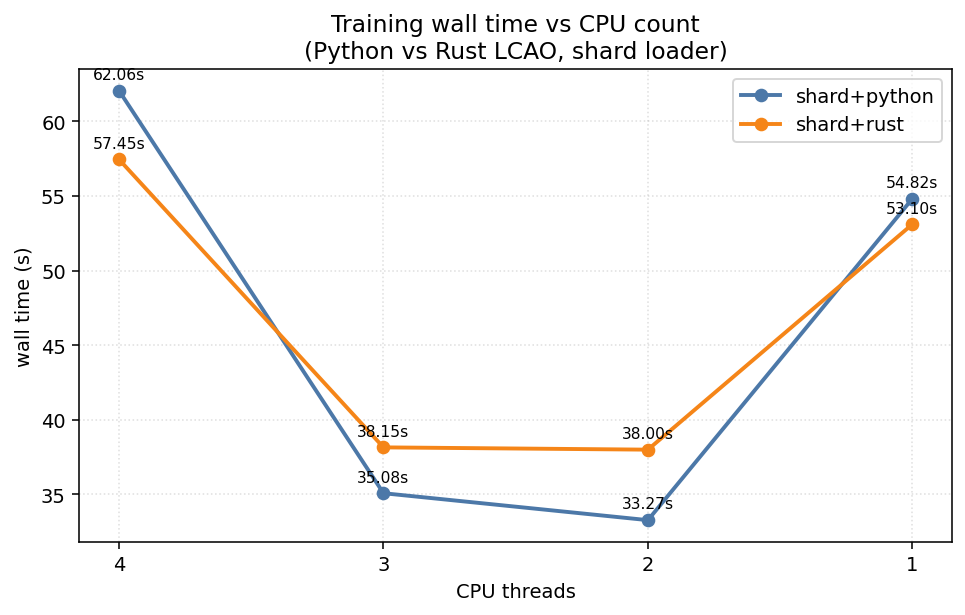

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/cpu_scale_speedup.png


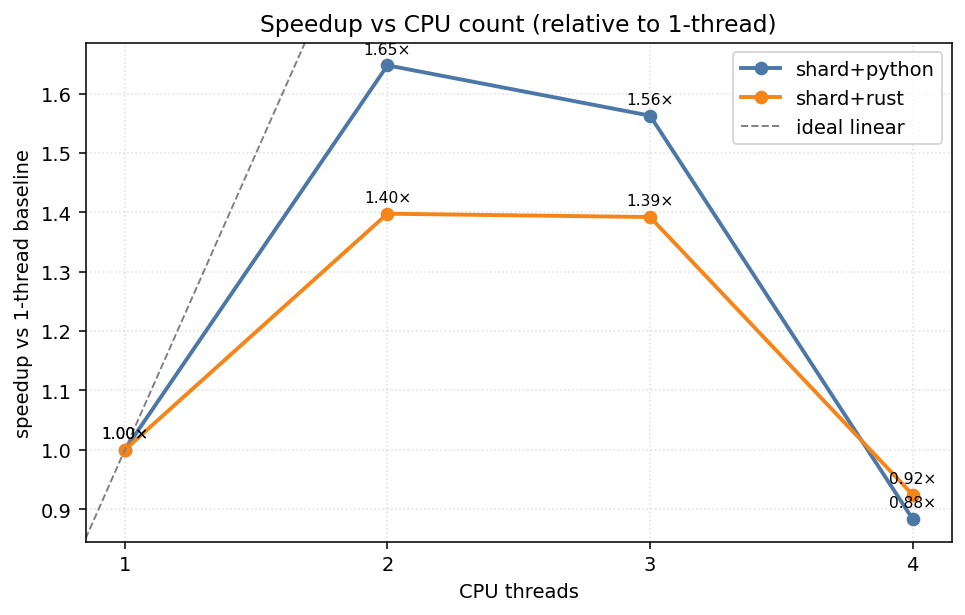

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/cpu_scale_bars.png


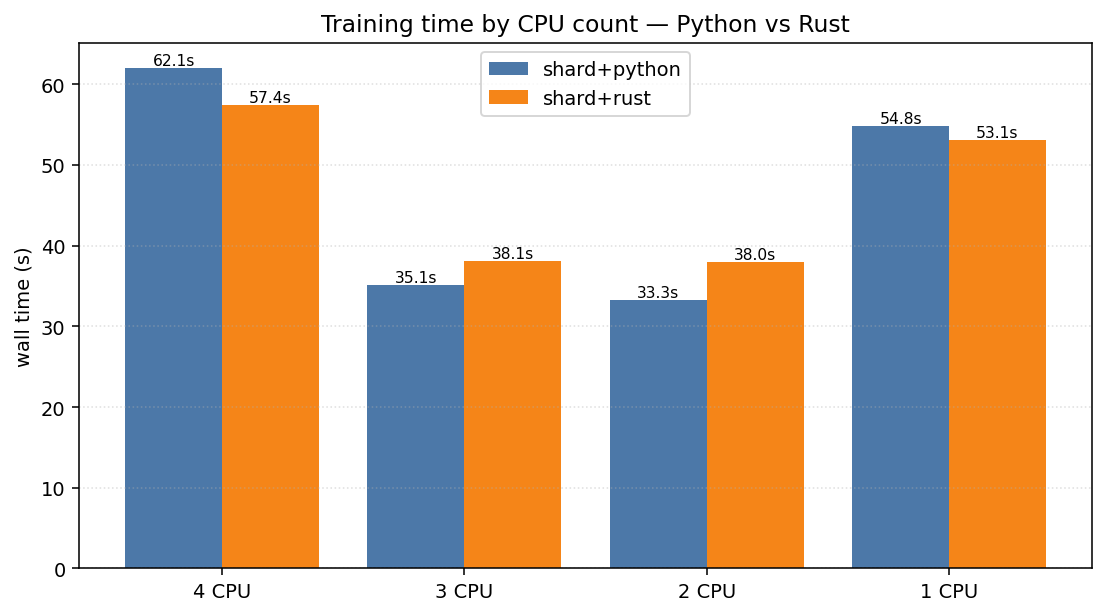

In [16]:
if not CPU_SCALE_RESULTS:
    print("CPU_SCALE_RESULTS is empty — run the cell above first.")
else:
    import matplotlib.pyplot as plt
    import numpy as np
    import time as _time

    def _save(fig, name):
        """Save PNG; works even if the main visualisation cell (§10.5) was not run yet."""
        save_figs = globals().get("SAVE_FIGS", True)
        fig_dir = globals().get("FIG_DIR")
        if fig_dir is None:
            ts = _time.strftime("%m%d_%H%M")
            n = int(globals().get("N_CPUS", 4))
            fig_dir = NB_DIR.resolve() / "figs" / f"{ts}_{n}cpu"
        if not save_figs:
            return
        fig_dir.mkdir(parents=True, exist_ok=True)
        path = fig_dir / f"{name}.png"
        fig.savefig(path, dpi=160, bbox_inches="tight")
        print(f"  saved {path}")

    # ---- organise by backend ----
    backends = list(dict.fromkeys(r["backend"] for r in CPU_SCALE_RESULTS))
    cpus_present = sorted(set(r["n_cpu"] for r in CPU_SCALE_RESULTS), reverse=True)
    COLORS = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

    def _wall(r):
        v = r.get("counted_total_s") or r.get("wall_s") or 0.0
        return float(v)

    # ---- (a) line chart: wall-time vs CPU count ----
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=140)
    for bi, be in enumerate(backends):
        rows = [r for r in CPU_SCALE_RESULTS if r["backend"] == be]
        rows.sort(key=lambda r: r["n_cpu"])
        xs = [r["n_cpu"] for r in rows]
        ys = [_wall(r) for r in rows]
        ax.plot(xs, ys, marker="o", linewidth=2, color=COLORS[bi % len(COLORS)], label=be)
        for x, y in zip(xs, ys):
            ax.annotate(f"{y:.2f}s", (x, y), textcoords="offset points",
                        xytext=(0, 6), ha="center", fontsize=8)
    ax.set_xlabel("CPU threads")
    ax.set_ylabel("wall time (s)")
    ax.set_title("Training wall time vs CPU count\n(Python vs Rust LCAO, shard loader)")
    ax.set_xticks(cpus_present)
    ax.invert_xaxis()
    ax.legend()
    ax.grid(linestyle=":", alpha=0.4)
    fig.tight_layout()
    _save(fig, "cpu_scale_walltime")
    plt.show()

    # ---- (b) speedup relative to 1-cpu baseline per backend ----
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=140)
    for bi, be in enumerate(backends):
        rows = sorted([r for r in CPU_SCALE_RESULTS if r["backend"] == be],
                      key=lambda r: r["n_cpu"])
        base1 = next((r for r in rows if r["n_cpu"] == 1), None)
        if base1 is None:
            continue
        t1 = _wall(base1)
        xs = [r["n_cpu"] for r in rows]
        ys = [t1 / _wall(r) if _wall(r) > 0 else 0 for r in rows]
        ax.plot(xs, ys, marker="o", linewidth=2, color=COLORS[bi % len(COLORS)], label=be)
        for x, y in zip(xs, ys):
            ax.annotate(f"{y:.2f}×", (x, y), textcoords="offset points",
                        xytext=(0, 6), ha="center", fontsize=8)
    ax.axline((1, 1), slope=1, color="gray", linestyle="--", linewidth=1, label="ideal linear")
    ax.set_xlabel("CPU threads")
    ax.set_ylabel("speedup vs 1-thread baseline")
    ax.set_title("Speedup vs CPU count (relative to 1-thread)")
    ax.set_xticks(cpus_present)
    ax.legend()
    ax.grid(linestyle=":", alpha=0.4)
    fig.tight_layout()
    _save(fig, "cpu_scale_speedup")
    plt.show()

    # ---- (c) grouped bar chart (each cpu count = one group, bars = backends) ----
    x = np.arange(len(cpus_present))
    w = 0.8 / len(backends)
    fig, ax = plt.subplots(figsize=(max(6, 2*len(cpus_present)), 4.5), dpi=140)
    for bi, be in enumerate(backends):
        vals = []
        for n in cpus_present:
            row = next((r for r in CPU_SCALE_RESULTS if r["backend"] == be and r["n_cpu"] == n), None)
            vals.append(_wall(row) if row else 0.0)
        offset = (bi - (len(backends)-1)/2) * w
        bars = ax.bar(x + offset, vals, w, label=be, color=COLORS[bi % len(COLORS)])
        for b, v in zip(bars, vals):
            if v > 0:
                ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}s",
                        ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{n} CPU" for n in cpus_present])
    ax.set_ylabel("wall time (s)")
    ax.set_title("Training time by CPU count — Python vs Rust")
    ax.legend()
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    fig.tight_layout()
    _save(fig, "cpu_scale_bars")
    plt.show()

### 10.4 결과 요약 테이블

`BENCH_RESULTS` 에 모인 모든 실행을 한 표로 보여줍니다. **`subproc(s)`** = sampler가 잰 **프로세스 전체** 시간, **`script(s)`** = `profile_preprocess` stdout 의 **내부 hot-loop** 시간(있을 때만; bash와 동일 잣대). NumPy ↔ Rust 비교는 같은 `group` 안에서 첫 행 대비 speedup도 출력하며, speedup은 **`script(s)`가 있으면 그 값**, 없으면 `subproc(s)`를 씁니다.

In [17]:
def _cmp_wall(r: dict) -> float:
    """Wall time comparable to a bare ``python profile_preprocess.py`` run.

    Uses ``script_wall_s`` (parsed from the script's ``wall time : …`` line) when
    present — that matches the hot-loop timer inside ``profile_preprocess.py``.
    Falls back to ``wall_s`` (sampler: whole subprocess, includes startup + imports).
    """
    sw = r.get("script_wall_s")
    if sw is not None:
        return float(sw)
    return float(r.get("wall_s") or 0.0)


if not BENCH_RESULTS:
    print("BENCH_RESULTS is empty — run the cells in 10.1 / 10.2 first.")
else:
    # (header, width, align, key, value-format)  — use key "_script_wall" for parsed inner wall
    cols = [
        ("label",        32, "<", "label",         "{:<32s}"),
        ("group",        10, "<", "group",         "{:<10s}"),
        ("subproc(s)",   10, ">", "wall_s",        "{:>10.3f}"),
        ("script(s)",   9, ">", "_script_wall",  "{:>9.3f}"),
        ("peakRSS(MB)",  12, ">", "peak_rss_mb",  "{:>12.1f}"),
        ("meanCPU%",     10, ">", "mean_cpu_pct", "{:>10.1f}"),
        ("peakCPU%",     10, ">", "peak_cpu_pct", "{:>10.1f}"),
        ("meanXPU%",     10, ">", "mean_xpu_pct", "{:>10.1f}"),
        ("peakXPU%",     10, ">", "peak_xpu_pct", "{:>10.1f}"),
    ]

    header_cells = []
    for name, width, align, _, _ in cols:
        header_cells.append(f"{name:{align}{width}}")
    header_line = "  ".join(header_cells)
    print(header_line)
    print("-" * len(header_line))

    for r in BENCH_RESULTS:
        row_cells = []
        for name, width, align, key, fmt in cols:
            if key == "_script_wall":
                sw = r.get("script_wall_s")
                if isinstance(sw, (int, float)):
                    row_cells.append(fmt.format(sw))
                else:
                    row_cells.append(f"{'n/a':>9}")
                continue
            v = r.get(key)
            if isinstance(v, (int, float)):
                row_cells.append(fmt.format(v))
            else:
                row_cells.append(f"{str(v):{align}{width}}")
        print("  ".join(row_cells))

    print(
        "\n--- speedup (uses script(s) when present, else subproc(s); first row = baseline) ---"
    )
    groups: dict[str, list[dict]] = {}
    for r in BENCH_RESULTS:
        groups.setdefault(r["group"], []).append(r)
    for grp, rows in groups.items():
        base = rows[0]
        bw = _cmp_wall(base)
        print(f"\n[{grp}]  baseline = {base['label']}  cmp_wall={bw:.3f}s")
        for r in rows:
            rw = _cmp_wall(r)
            sp = bw / rw if rw > 0 else float("nan")
            print(f"  {r['label']:<32s}  cmp_wall={rw:7.3f}s  x{sp:5.2f}")

label                             group       subproc(s)  script(s)   peakRSS(MB)    meanCPU%    peakCPU%    meanXPU%    peakXPU%
---------------------------------------------------------------------------------------------------------------------------------
preprocess[numpy]                 preprocess       6.627      6.018         229.6        26.8        87.4         0.0         0.0
preprocess[rust]                  preprocess       1.123      0.515         226.0        50.5        87.5         0.0         0.0
train[npy+python,bs=8]            train           18.879        n/a         775.4        81.8        99.1         0.0         0.0
train[shard+python,bs=8]          train           18.375        n/a        1062.0        82.6       100.3         0.0         0.0
train[shard+rust-pad-only,bs=8]   train           18.883        n/a        1004.1        81.9       100.4         0.0         0.0
train[shard+rust,bs=8]            train           67.350        n/a        1042.0        4

### 10.5 시각화 — 막대 그래프 + 시계열

각 그룹(preprocess / train)별로:

- **막대 그래프**: 첫 칸은 **가능하면 스크립트 내부 `wall time`(stdout)** — bash와 동일한 잣대. 없으면(학습 등) **서브프로세스 전체 `wall_s`**. 나머지는 peak RSS, mean CPU%, mean XPU%.
- **시계열**: 각 run의 CPU% / RSS / XPU% 시간 변화

같은 metric을 같은 단위로 그려 두면 한 눈에 NumPy ↔ Rust 차이가 보입니다.

FIG_DIR       : /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu
  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/bars_preprocess.png


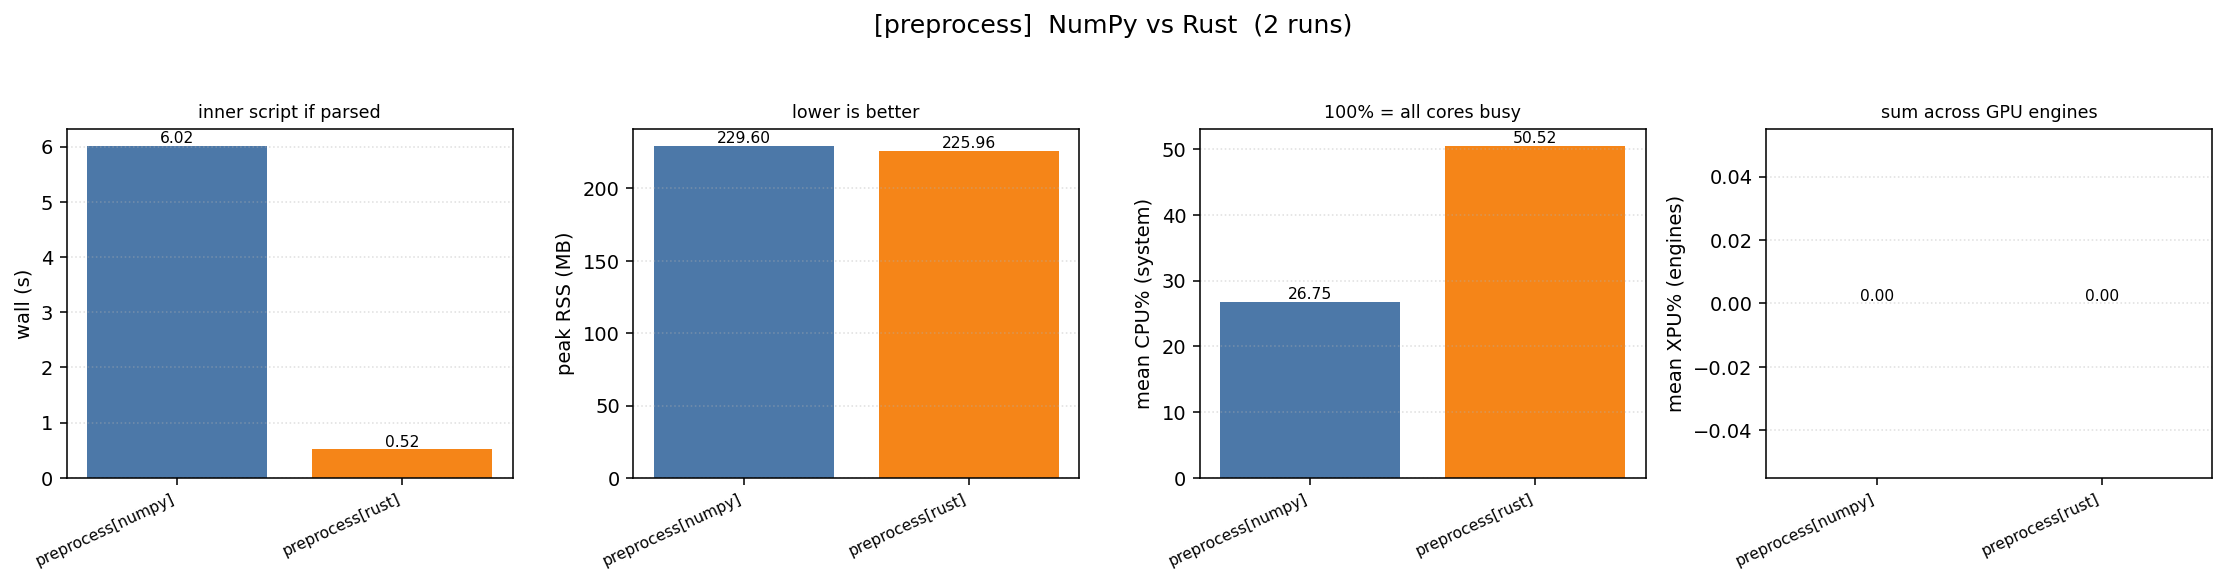

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/timeseries_preprocess.png


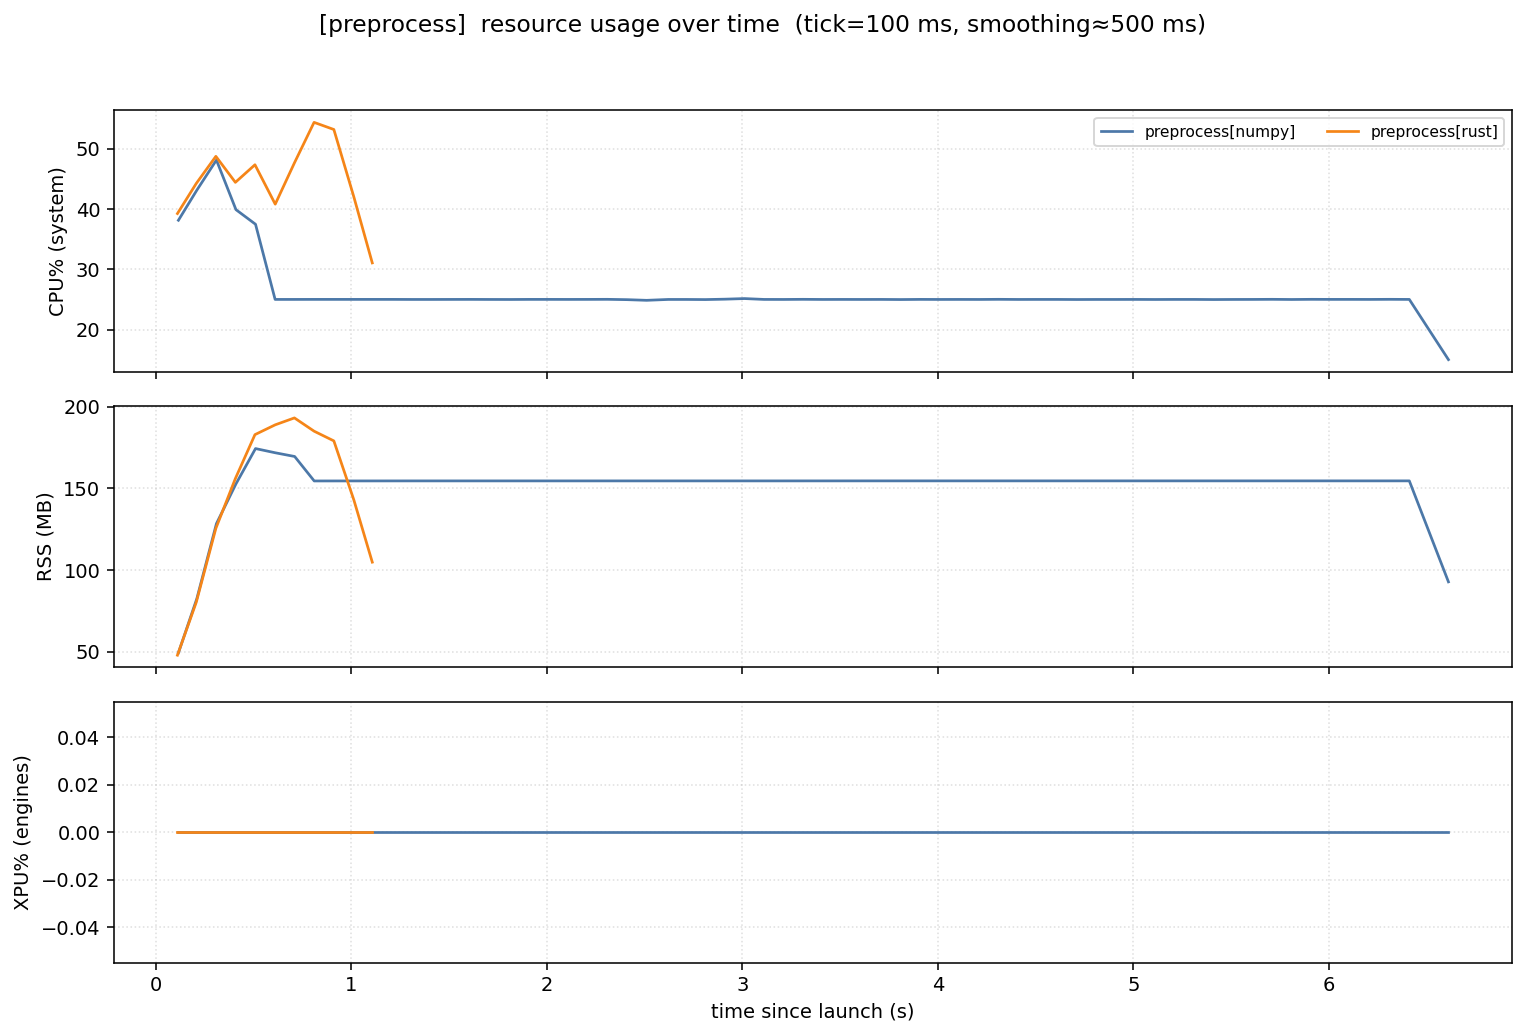

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/cpu_xpu_preprocess.png


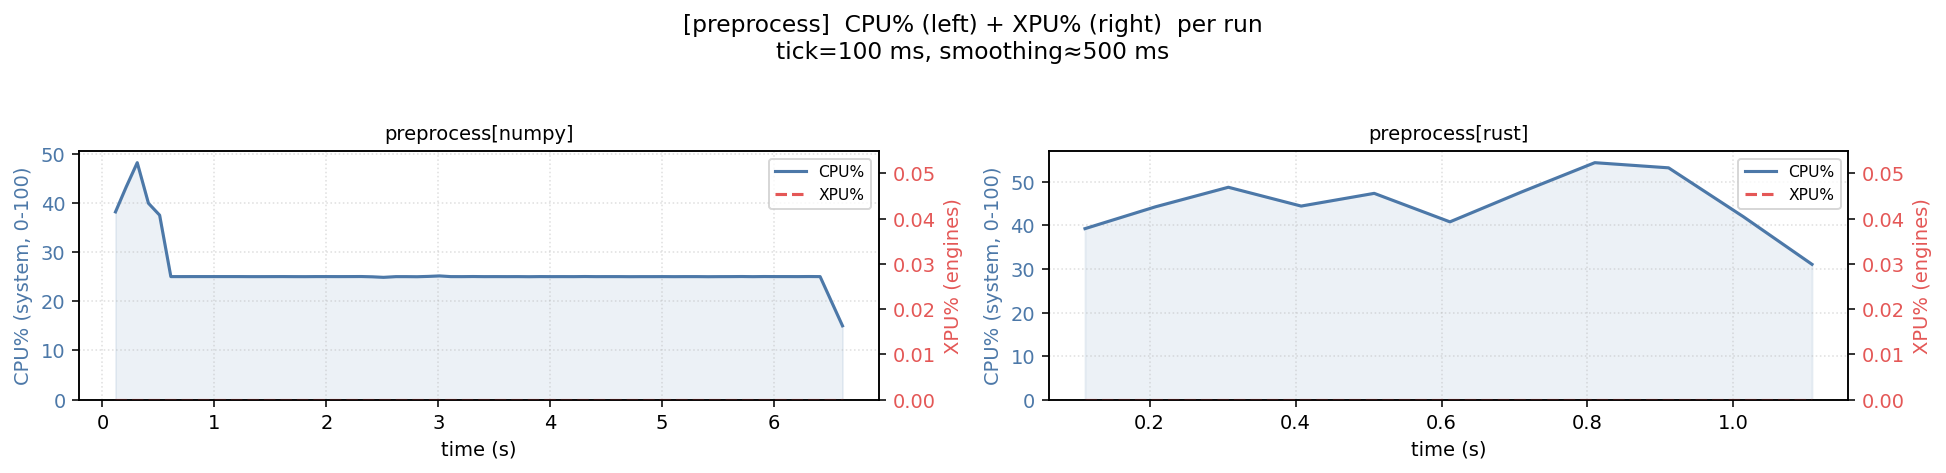

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/bars_train.png


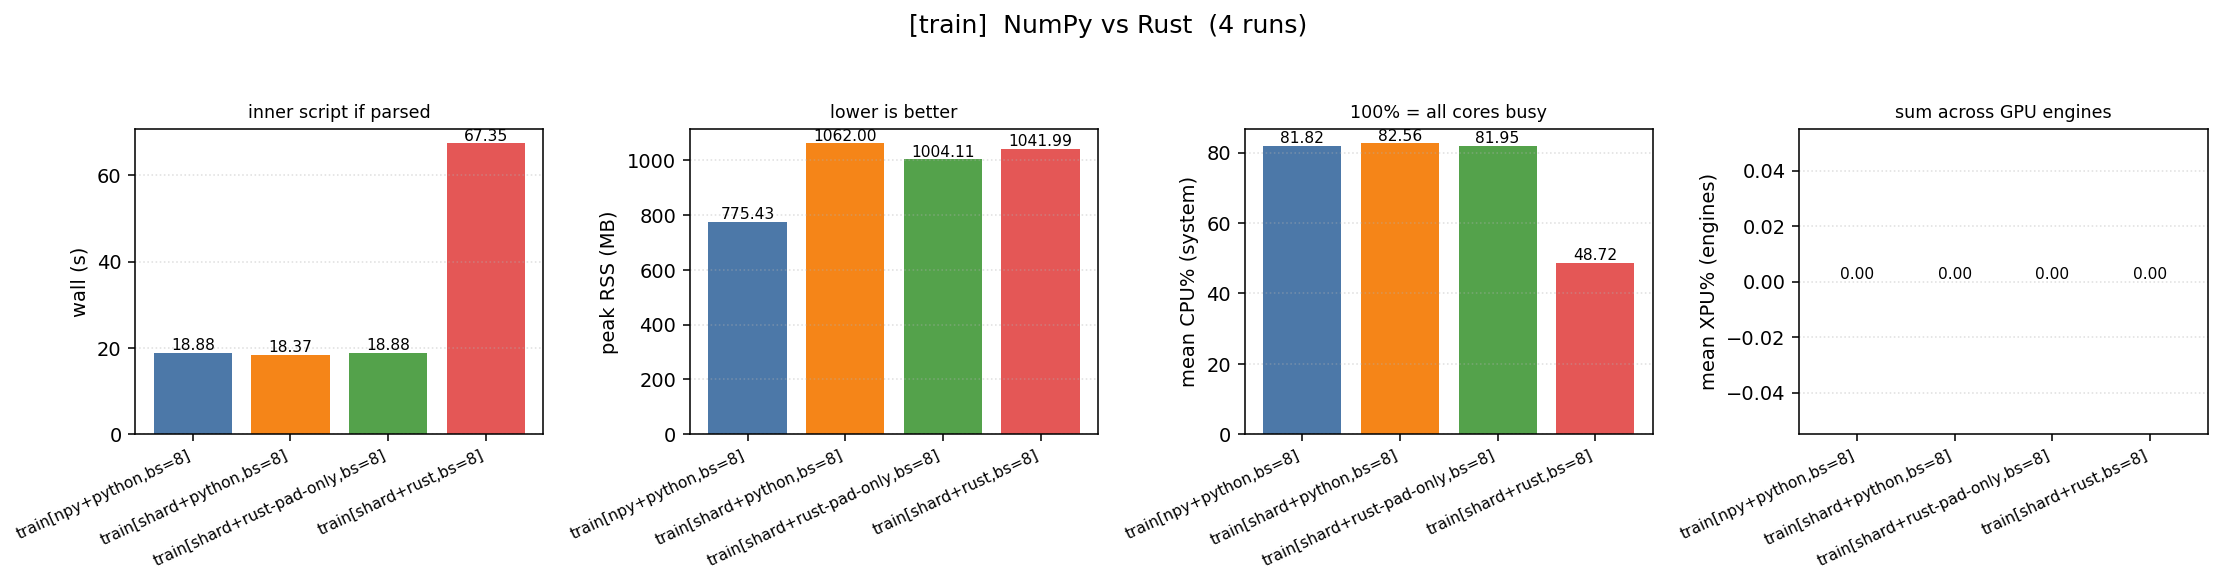

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/timeseries_train.png


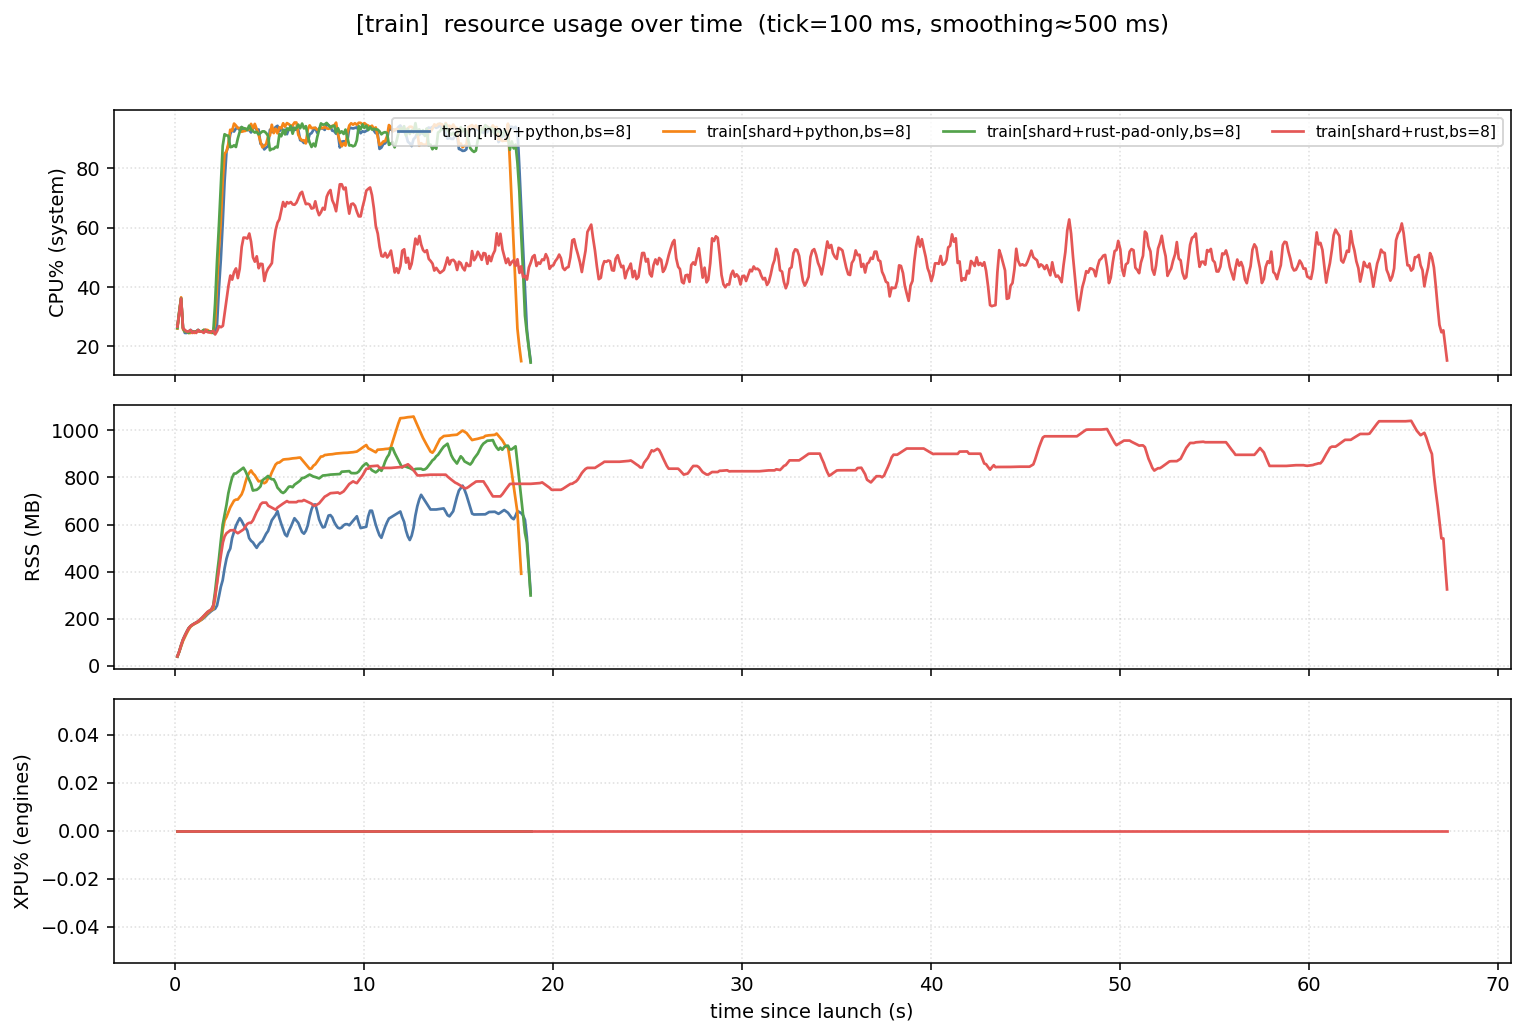

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/cpu_xpu_train.png


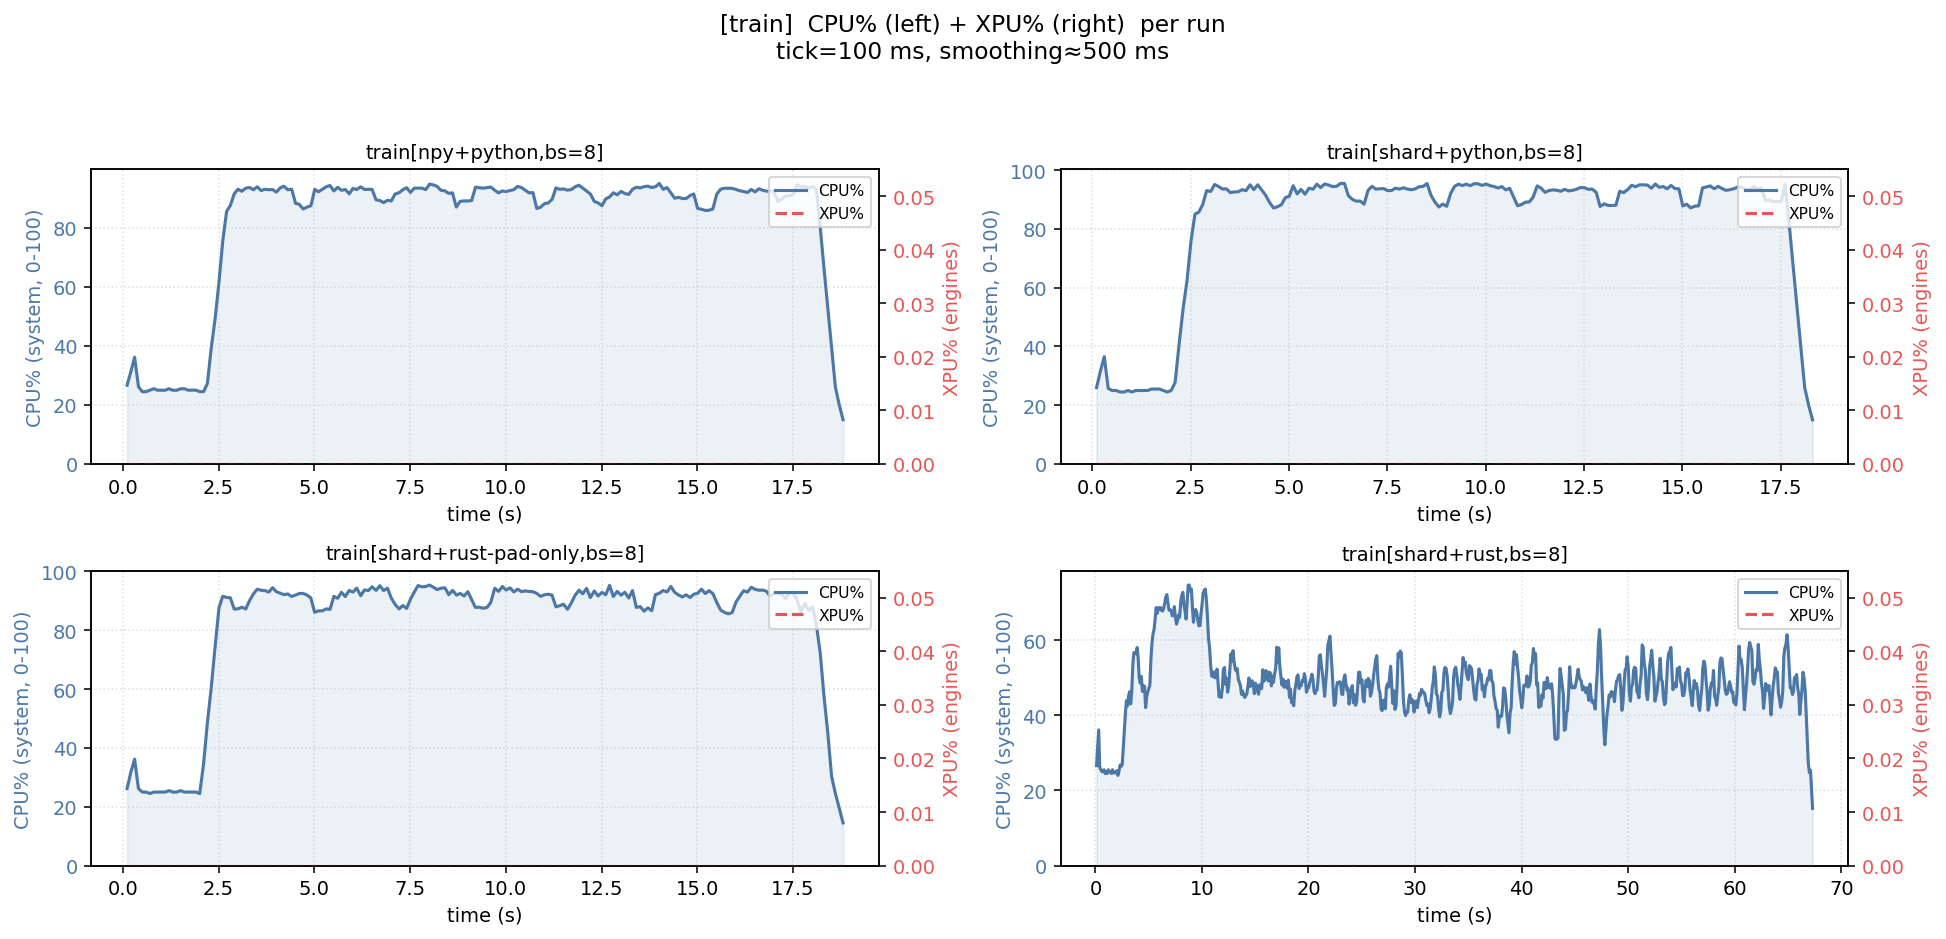

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/bars_cpu_scale.png


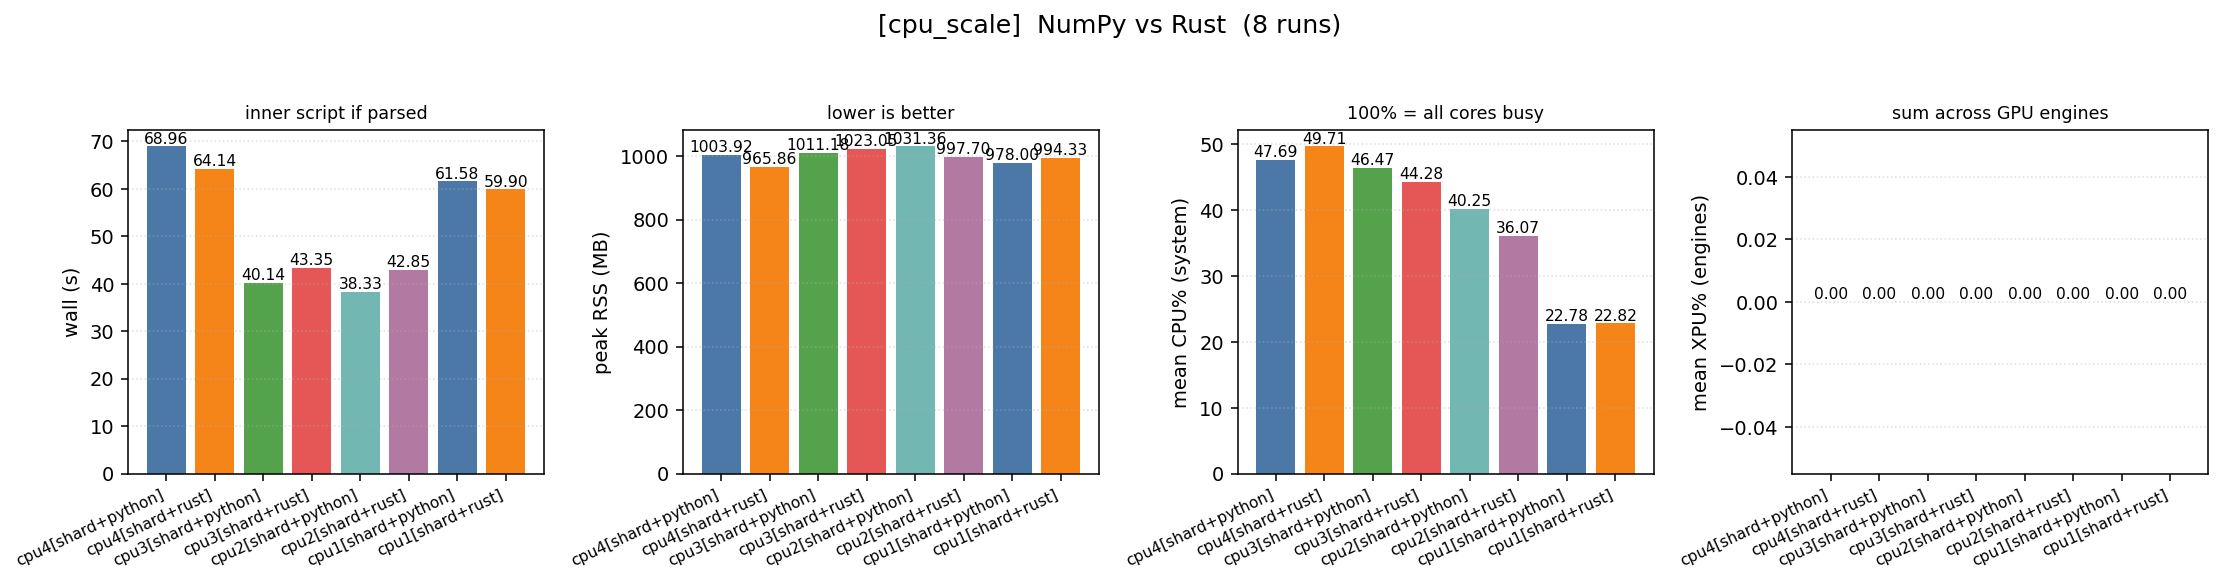

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/timeseries_cpu_scale.png


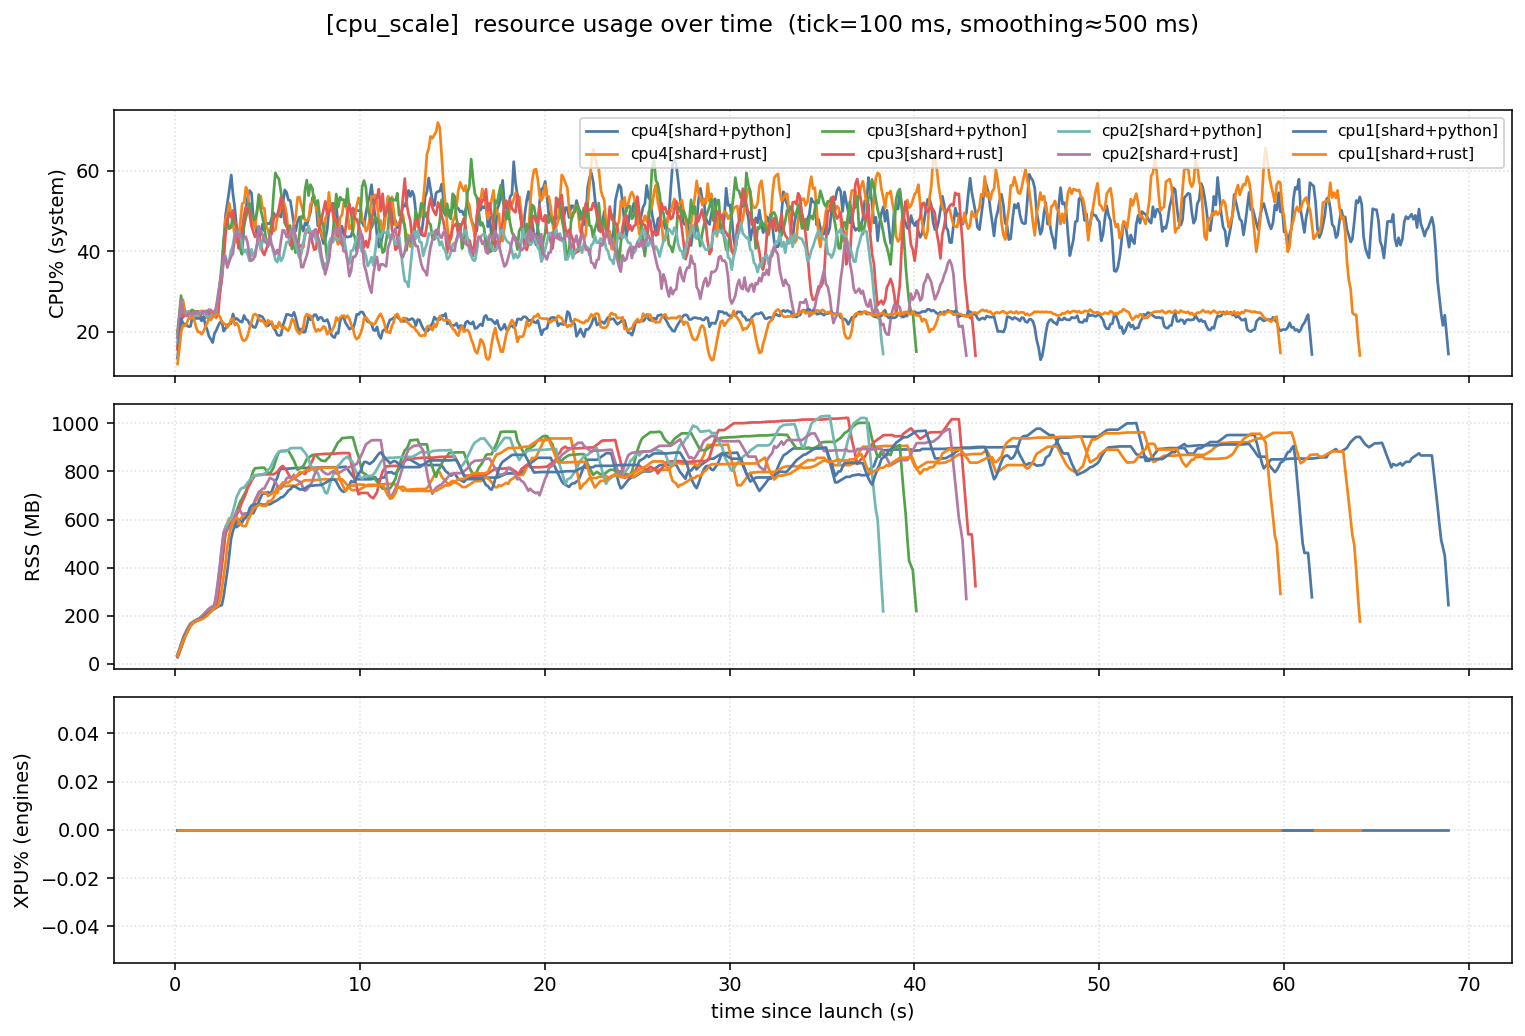

  saved /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/figs/0514_2342_4cpu/cpu_xpu_cpu_scale.png


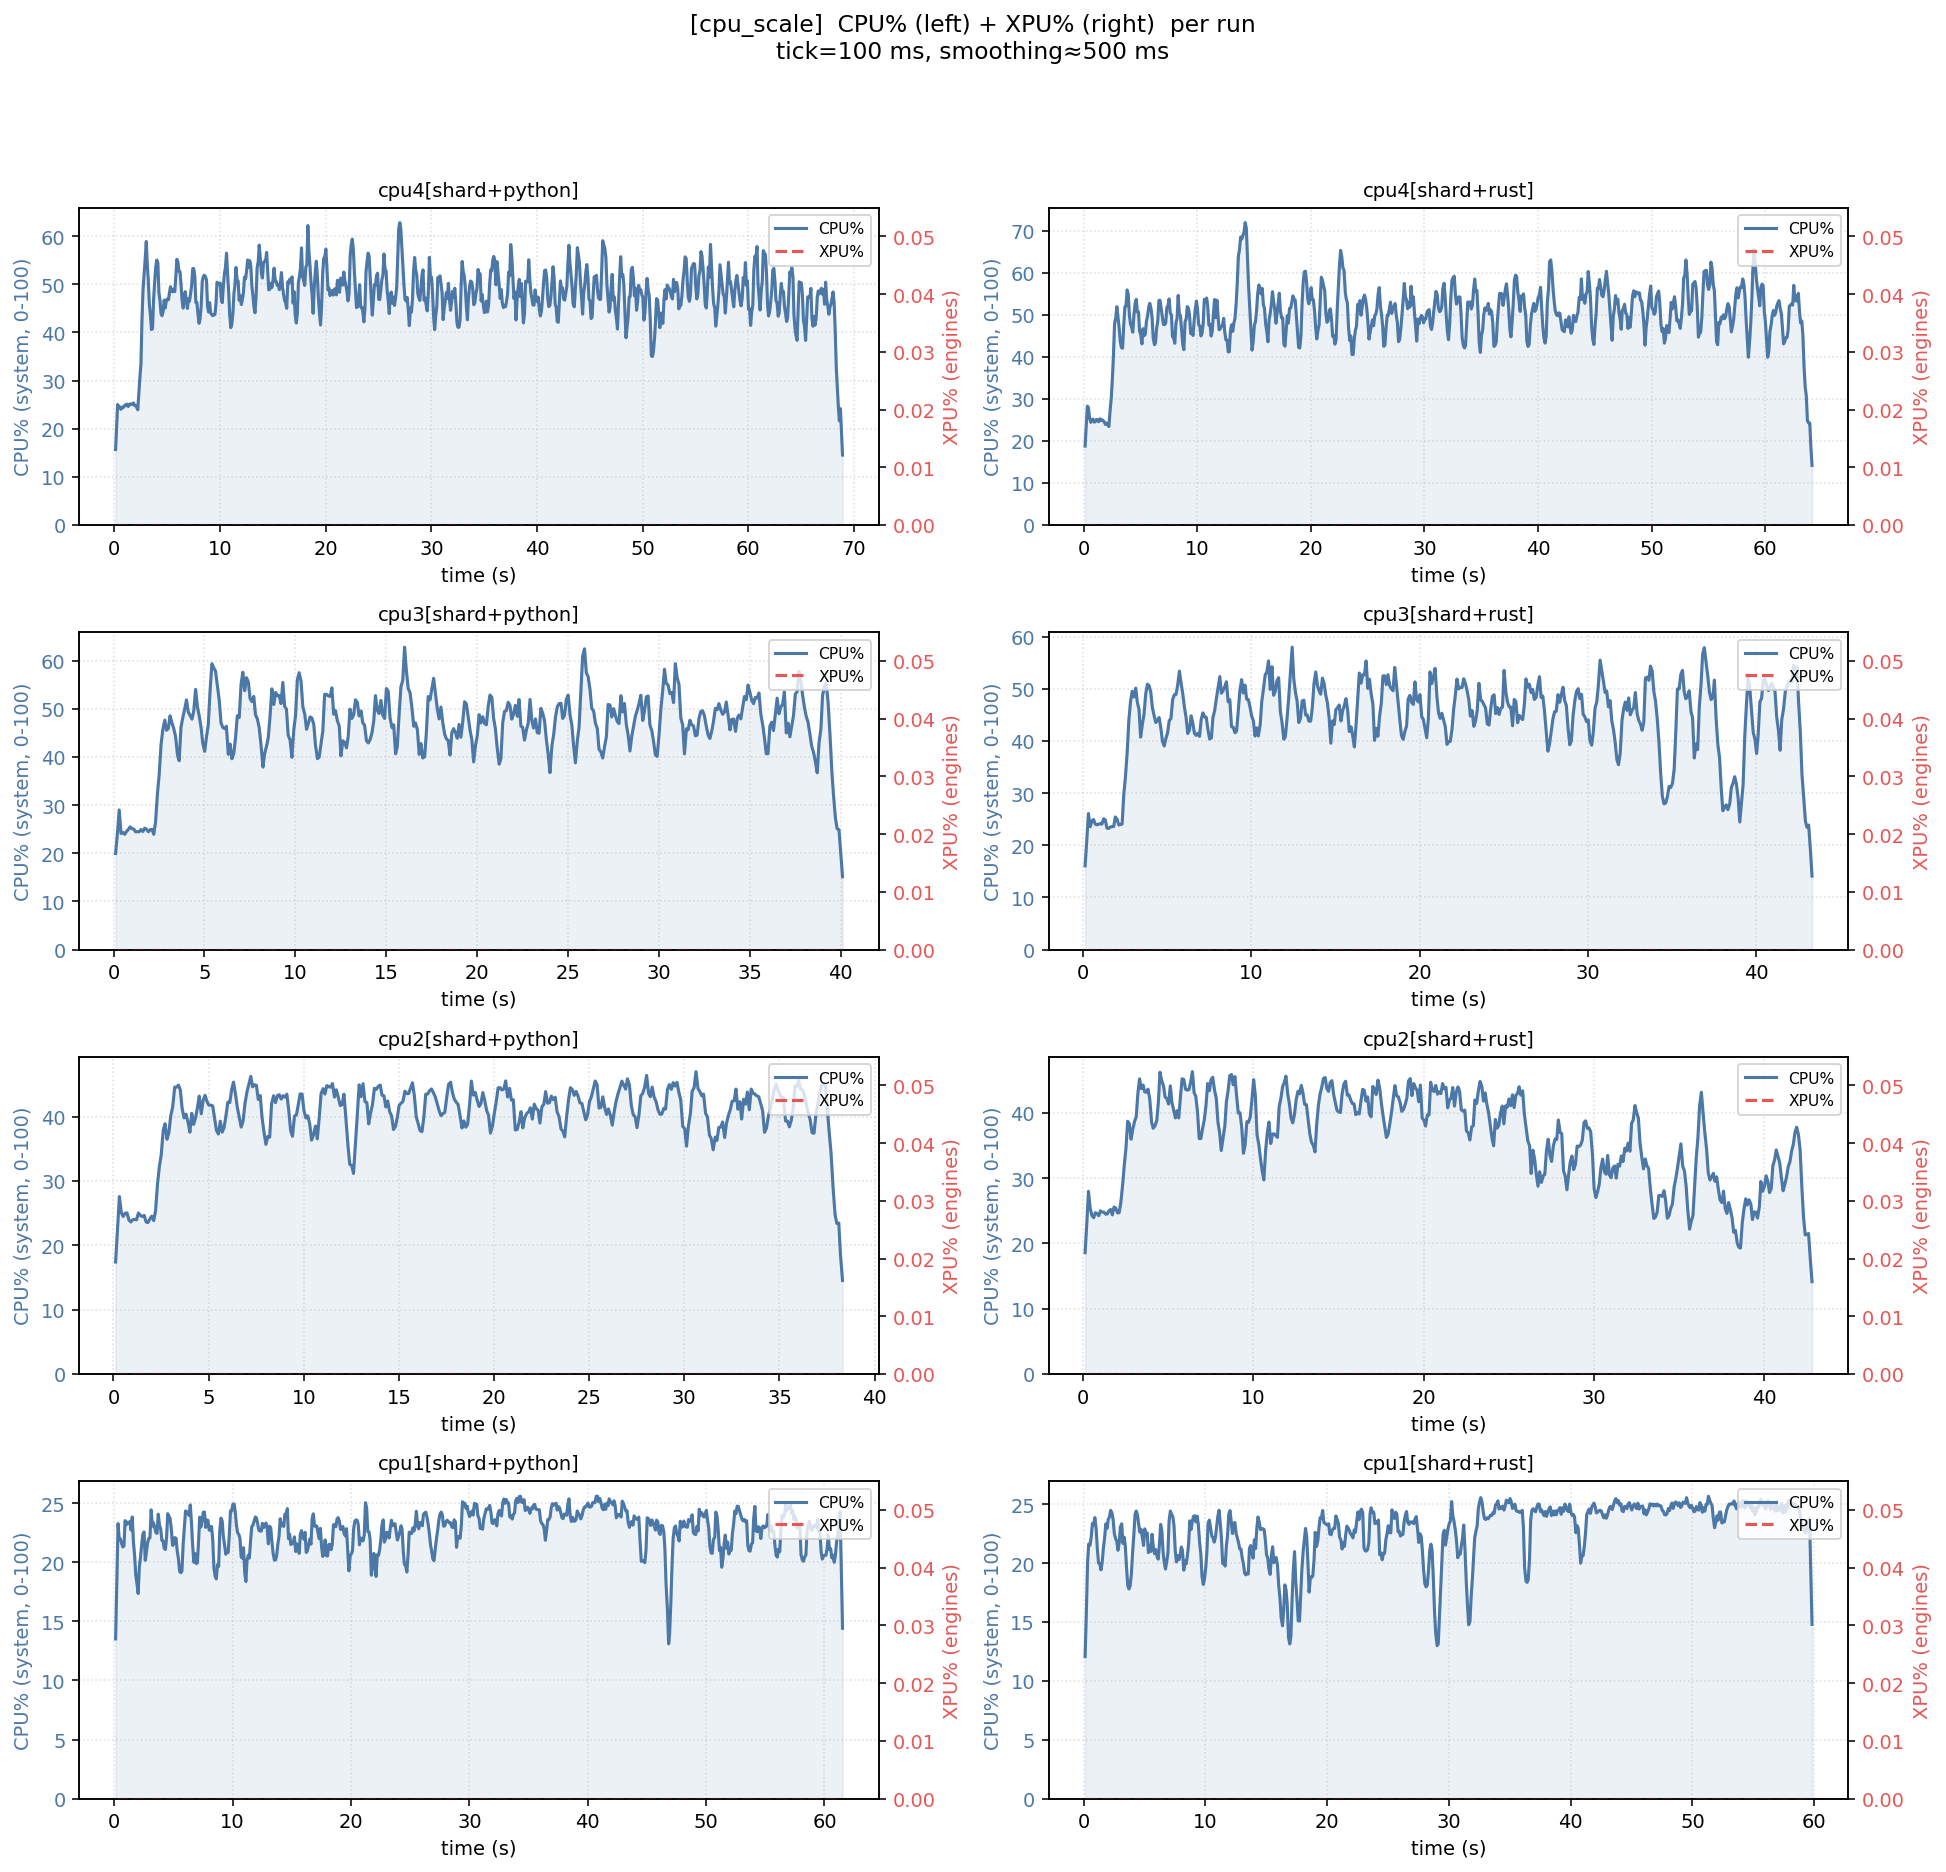

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Note: PDH `\GPU Engine(*)` is per-engine and we sum across engines for each
# PID, so XPU% can exceed 100% (e.g. 3D engine 70% + compute engine 50% = 120%).
# Treat the bars as "relative busy-ness", not as a fraction of one device.

# PNG outputs: bench/figs/{MMDD_HHMM}_{N_CPUS}cpu/ — one folder per run.
import time as _time
SAVE_FIGS = True
FIG_TS = _time.strftime("%m%d_%H%M")
FIG_DIR = NB_DIR.resolve() / "figs" / f"{FIG_TS}_{N_CPUS}cpu"
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    print(f"FIG_DIR       : {FIG_DIR}")

# Smooth noisy 10 Hz traces with a centered moving average. Window length is
# derived from the sample interval so the on-screen smoothing duration is
# consistent regardless of how dense the samples are.
SMOOTH_WINDOW_S = 0.5

def _smooth(arr, dt_s):
    a = np.asarray(arr, dtype=float)
    if a.size == 0 or dt_s <= 0:
        return a
    w = max(1, int(round(SMOOTH_WINDOW_S / dt_s)))
    if w <= 1 or a.size < w:
        return a
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(a, kernel, mode="same")

def _dt(samples):
    t = samples.t
    if len(t) < 2:
        return SAMPLE_INTERVAL_S
    return max(1e-6, float(np.median(np.diff(t))))


def _save(fig, name):
    if SAVE_FIGS:
        path = FIG_DIR / f"{name}.png"
        fig.savefig(path, dpi=160, bbox_inches="tight")
        print(f"  saved {path}")


# ---------------------------------------------------------------------------
if not BENCH_RESULTS:
    print("BENCH_RESULTS is empty — run the cells in 10.1 / 10.2 first.")
else:
    def _cmp_wall(r: dict) -> float:
        sw = r.get("script_wall_s")
        if sw is not None:
            return float(sw)
        return float(r.get("wall_s") or 0.0)

    groups: dict[str, list[dict]] = {}
    for r in BENCH_RESULTS:
        groups.setdefault(r["group"], []).append(r)

    PALETTE = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"]

    metric_cols = [
        ("_cmp_wall",    "wall (s)",             "inner script if parsed"),
        ("peak_rss_mb",  "peak RSS (MB)",        "lower is better"),
        ("mean_cpu_pct", "mean CPU% (system)",   "100% = all cores busy"),
        ("mean_xpu_pct", "mean XPU% (engines)",  "sum across GPU engines"),
    ]

    for grp, rows in groups.items():
        labels = [r["label"] for r in rows]
        n = len(rows)
        colors = [PALETTE[i % len(PALETTE)] for i in range(n)]
        x = list(range(n))

        # ---- (a) bar chart of scalar summaries ----
        fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), dpi=140)
        fig.suptitle(f"[{grp}]  NumPy vs Rust  ({n} runs)", fontsize=13)
        for ax, (key, ylabel, sub) in zip(axes, metric_cols):
            if key == "_cmp_wall":
                vals = [_cmp_wall(r) for r in rows]
            else:
                vals = [r.get(key) or 0.0 for r in rows]
            bars = ax.bar(x, vals, color=colors)
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
            ax.set_ylabel(ylabel)
            ax.set_title(sub, fontsize=9)
            ax.grid(axis="y", linestyle=":", alpha=0.4)
            for b, v in zip(bars, vals):
                ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}",
                        ha="center", va="bottom", fontsize=8)
        fig.tight_layout(rect=[0, 0, 1, 0.94])
        _save(fig, f"bars_{grp}")
        plt.show()

        # ---- (b) overlay time series of CPU / RSS / XPU across runs ----
        fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True, dpi=140)
        fig.suptitle(f"[{grp}]  resource usage over time  "
                     f"(tick={SAMPLE_INTERVAL_S*1000:.0f} ms, "
                     f"smoothing≈{SMOOTH_WINDOW_S*1000:.0f} ms)", fontsize=12)
        for r, c in zip(rows, colors):
            s = r["samples"]
            if not s.t:
                continue
            dt = _dt(s)
            axes[0].plot(s.t, _smooth(s.cpu_pct, dt), label=r["label"], color=c, linewidth=1.4)
            axes[1].plot(s.t, _smooth(s.rss_mb,  dt), label=r["label"], color=c, linewidth=1.4)
            axes[2].plot(s.t, _smooth(s.xpu_pct, dt), label=r["label"], color=c, linewidth=1.4)
        axes[0].set_ylabel("CPU% (system)")
        axes[1].set_ylabel("RSS (MB)")
        axes[2].set_ylabel("XPU% (engines)")
        axes[2].set_xlabel("time since launch (s)")
        for ax in axes:
            ax.grid(linestyle=":", alpha=0.4)
        axes[0].legend(fontsize=8, ncol=min(4, len(rows)), loc="upper right")
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        _save(fig, f"timeseries_{grp}")
        plt.show()

        # ---- (c) combined CPU + XPU per run, twin axes ----
        cols = min(2, n)
        grid_rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(
            grid_rows, cols,
            figsize=(7.0 * cols, 3.4 * grid_rows),
            dpi=140, squeeze=False,
        )
        fig.suptitle(
            f"[{grp}]  CPU% (left) + XPU% (right)  per run\n"
            f"tick={SAMPLE_INTERVAL_S*1000:.0f} ms, smoothing≈{SMOOTH_WINDOW_S*1000:.0f} ms",
            fontsize=12,
        )
        axes_flat = [ax for row_ in axes for ax in row_]
        for ax, r in zip(axes_flat, rows):
            s = r["samples"]
            ax.set_title(r["label"], fontsize=10)
            ax.set_xlabel("time (s)")
            ax.grid(linestyle=":", alpha=0.4)
            if not s.t:
                ax.text(0.5, 0.5, "no samples", ha="center", va="center",
                        transform=ax.transAxes)
                continue
            dt = _dt(s)
            cpu = _smooth(s.cpu_pct, dt)
            xpu = _smooth(s.xpu_pct, dt)
            l1, = ax.plot(s.t, cpu, color="#4C78A8", linewidth=1.6, label="CPU%")
            ax.set_ylabel("CPU% (system, 0-100)", color="#4C78A8")
            ax.tick_params(axis="y", labelcolor="#4C78A8")
            ax.fill_between(s.t, 0, cpu, color="#4C78A8", alpha=0.10)

            ax2 = ax.twinx()
            l2, = ax2.plot(s.t, xpu, color="#E45756", linewidth=1.6,
                           linestyle="--", label="XPU%")
            ax2.set_ylabel("XPU% (engines)", color="#E45756")
            ax2.tick_params(axis="y", labelcolor="#E45756")
            ax2.fill_between(s.t, 0, xpu, color="#E45756", alpha=0.10)

            # Force both axes to start at 0 — easier to read for reports.
            ax.set_ylim(bottom=0)
            ax2.set_ylim(bottom=0)
            ax.legend(handles=[l1, l2], loc="upper right", fontsize=8)
        # Hide any leftover empty subplots.
        for ax in axes_flat[len(rows):]:
            ax.set_visible(False)
        fig.tight_layout(rect=[0, 0, 1, 0.94])
        _save(fig, f"cpu_xpu_{grp}")
        plt.show()